In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import re
import warnings
warnings.filterwarnings('ignore')

# Cấu hình Matplotlib hỗ trợ tiếng Việt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-darkgrid')

print("[✓] Tất cả thư viện đã được tải thành công!")
print("=" * 80)

[✓] Tất cả thư viện đã được tải thành công!


In [6]:
# CELL 1: Load & Merge Dữ liệu + Data Profiling
print("\n" + "="*80)
print("PHẦN 1: TẢI DỮ LIỆU & PHÂN TÍCH CHẤT LƯỢNG DỮ LIỆU")
print("="*80)

# Đọc dữ liệu từ file cleaned
df_eda = pd.read_csv('data/1_data_cleaned_train.csv', index_col=0).reset_index()

# Loại bỏ các cột unnamed trùng lặp
cols = df_eda.columns
df_eda = df_eda.loc[:, ~(cols.duplicated())]

# Định nghĩa target column (cột cuối cùng hoặc 'Khoảng giá')
if 'Khoảng giá' in df_eda.columns:
    target_col = 'Khoảng giá'
elif df_eda.columns[-1] == 'target':
    target_col = 'target'
else:
    target_col = df_eda.columns[-1]
    
print(f"[✓] Target column: {target_col}")

print(f"\n[✓] Dữ liệu đã được tải thành công!")
print(f"    Shape: {df_eda.shape}")
print(f"\n[✓] 5 Dòng đầu tiên của DataFrame:")
print(df_eda.head())

# Hàm Data Profiling nâng cao với xử lý lỗi
def data_profiling(df):
    """
    Hàm xuất bảng thống kê chất lượng dữ liệu
    """
    profile_data = []
    for i, col in enumerate(df.columns):
        try:
            # Sử dụng iloc để tránh vấn đề với tên cột đặc biệt
            col_data = df.iloc[:, i]
            missing_count = col_data.isnull().sum()
            missing_pct = (missing_count / len(df)) * 100
            unique_count = col_data.nunique()
            col_dtype = str(col_data.dtype)
            
            profile_data.append({
                'Column': col,
                'Dtype': col_dtype,
                'Missing_Count': missing_count,
                'Missing_%': f"{missing_pct:.2f}%",
                'Unique_Values': unique_count
            })
        except Exception as e:
            print(f"[⚠] Lỗi xử lý cột '{col}': {str(e)}")
            continue
    
    return pd.DataFrame(profile_data)

df_profile = data_profiling(df_eda)

print(f"\n[✓] BẢNG THỐNG KÊ CHẤT LƯỢNG DỮ LIỆU:")
print(df_profile.to_string(index=False))

# Tóm tắt
print(f"\n[SUMMARY] Chất lượng dữ liệu:")
print(f"    - Tổng số cột: {len(df_eda.columns)}")
print(f"    - Tổng số dòng: {len(df_eda)}")
print(f"    - Cột không có dữ liệu khuyết: {(df_profile['Missing_Count'] == 0).sum()}")
print(f"    - Cột có dữ liệu khuyết: {(df_profile['Missing_Count'] > 0).sum()}")


PHẦN 1: TẢI DỮ LIỆU & PHÂN TÍCH CHẤT LƯỢNG DỮ LIỆU
[✓] Target column: Khoảng giá

[✓] Dữ liệu đã được tải thành công!
    Shape: (4937, 19)

[✓] 5 Dòng đầu tiên của DataFrame:
   Diện tích  Số tầng  Đường vào  Pháp lý         Nội thất   Latitude  \
0       82.0      3.0   4.000000  Sổ hồng           Cơ bản  10.819863   
1       59.0      4.0   4.000000  Sổ hồng  Trống / Nhà thô  10.791452   
2       96.0      3.0  10.533333  Sổ hồng           Đầy đủ  10.764882   
3       66.0      2.0   4.000000  Sổ hồng  Trống / Nhà thô  10.790658   
4       75.0      3.0  10.000000  Sổ hồng  Trống / Nhà thô  21.028949   

    Longitude Loại đường vào        Quan_Huyen            Phuong_Xa  \
0  106.702744       Mặt tiền   Quận Bình Thạnh            Phường 13   
1  106.675114  Chưa xác định    Quận Phú Nhuận            Phường 11   
2  106.694973       Mặt tiền            Quận 1  Phường Cầu Ông Lãnh   
3  106.573008  Chưa xác định  Huyện Bình Chánh        Xã Vĩnh Lộc B   
4  105.852447  Chưa xác định 

In [11]:
# CELL 2: Descriptive Statistics - Phân tích Thống kê Mô tả
print("\n" + "="*80)
print("PHẦN 2: THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS)")
print("="*80)

# Lấy các cột số
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n[✓] Bảng Thống kê Chi tiết cho {len(numeric_cols)} biến số:")
desc_stats = df_eda[numeric_cols].describe().T

# Định dạng bảng để dễ đọc
desc_stats_formatted = desc_stats.round(4)
print(desc_stats_formatted)

print(f"\n[INSIGHT] Nhận xét về Phân vị (Percentiles):")
print(f"    - Các biến có phạm vi giá trị rất khác nhau")
print(f"    - Cột '25%' thể hiện 1/4 dữ liệu thấp nhất")
print(f"    - Cột '50%' (Median) = đường phân chia giữa dữ liệu")
print(f"    - Cột '75%' thể hiện 3/4 dữ liệu")

# Tìm các biến có độ lệch lớn (chỉ dấu outliers hoặc phân phối lệch)
print(f"\n[ANALYSIS] Các biến có max >> 75%:")
for col in numeric_cols:
    try:
        q75_val = df_eda[col].quantile(0.75)
        max_val = df_eda[col].max()
        
        # Chuyển Series sang scalar nếu cần
        if isinstance(q75_val, (pd.Series, np.ndarray)):
            q75_val = float(q75_val.item()) if hasattr(q75_val, 'item') else float(q75_val[0])
        if isinstance(max_val, (pd.Series, np.ndarray)):
            max_val = float(max_val.item()) if hasattr(max_val, 'item') else float(max_val[0])
        
        q75_val = float(q75_val)
        max_val = float(max_val)
        
        if q75_val > 0 and max_val / q75_val > 5:
            print(f"    - {col}: max ({max_val:.2f}) / Q75 ({q75_val:.2f}) = {max_val/q75_val:.1f}x (có thể có outliers)")
    except Exception as e:
        pass


PHẦN 2: THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS)

[✓] Bảng Thống kê Chi tiết cho 13 biến số:
                      count        mean         std      min       25%  \
Diện tích            4937.0     99.6468     92.2542   1.0000   52.0000   
Số tầng              4937.0      3.4645      1.4722   1.0000    2.0000   
Đường vào            4937.0      9.6015      6.6844   1.0000    5.0000   
Latitude             4937.0     10.9003      1.0485  10.3859   10.7661   
Longitude            4937.0    106.6622      1.1565  25.7209  106.6485   
Dien_Tich_Lo         3871.0  16641.0932  93963.3748   8.9000  160.5500   
duong_vao_null_flag  4937.0      0.3842      0.4865   0.0000    0.0000   
Ty_Le_Giao_Thong     3864.0     39.9967     36.4537   0.0000    5.6327   
Ty_Le_Cong_Cong_CX   3864.0     10.2565     25.6843   0.0000    0.0000   
Ty_Le_Khac           3864.0      6.4934     21.9671   0.0000    0.0000   
Ty_Le_Dat_O          3864.0     41.3957     39.8568   0.0000    0.4631   
Tổng số phòng      


PHẦN 3: PHÂN TÍCH PHÂN PHỐI BIẾN MỤC TIÊU (KHOẢNG GIÁ)


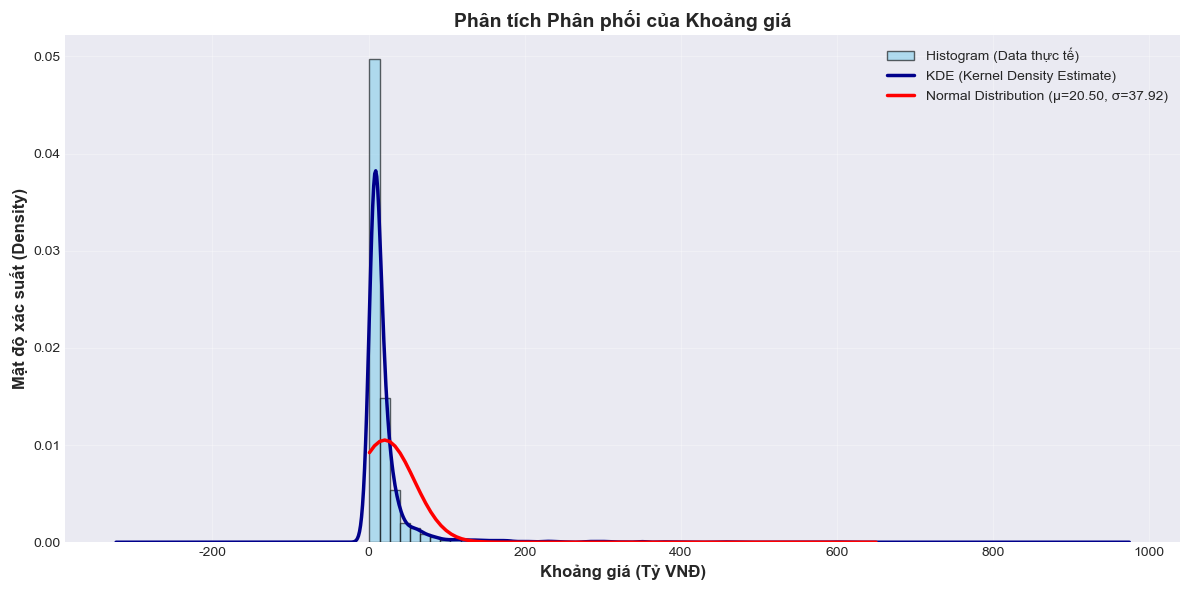


[STATISTICS] Chỉ số phân phối:
    - Mean (Trung bình): 20.5012
    - Median (Trung vị): 9.8000
    - Std Dev (Độ lệch chuẩn): 37.9248
    - Skewness (Độ lệch): 7.1400
      └─ Diễn giải: ⚠ Phân phối lệch PHẢI (dài đuôi bên phải)
    - Kurtosis (Độ nhọn): 71.7945
      └─ Diễn giải: ↑ Phân phối nhọn hơn bình thường (có tail nặng)


In [ ]:
# CELL 3: Phân tích Phân phối của Biến Mục tiêu 'Khoảng giá'
print("\n" + "="*80)
print("PHẦN 3: PHÂN TÍCH PHÂN PHỐI BIẾN MỤC TIÊU (KHOẢNG GIÁ)")
print("="*80)

target_col = 'Khoảng giá'
target_data = df_eda[target_col].dropna()

# Vẽ biểu đồ Histogram + KDE + Normal Distribution
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram + KDE thực tế
ax.hist(target_data, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Histogram (Data thực tế)')
target_data.plot(kind='density', ax=ax, color='darkblue', linewidth=2.5, label='KDE (Kernel Density Estimate)')

# Vẽ đè Normal Distribution (Phân phối chuẩn lý thuyết)
mu, sigma = target_data.mean(), target_data.std()
x = np.linspace(target_data.min(), target_data.max(), 100)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2.5, label=f'Normal Distribution (μ={mu:.2f}, σ={sigma:.2f})')

ax.set_xlabel(f'{target_col} (Tỷ VNĐ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mật độ xác suất (Density)', fontsize=12, fontweight='bold')
ax.set_title(f'Phân tích Phân phối của {target_col}', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tính Skewness và Kurtosis
skewness = stats.skew(target_data)
kurtosis = stats.kurtosis(target_data)

print(f"\n[STATISTICS] Chỉ số phân phối:")
print(f"    - Mean (Trung bình): {target_data.mean():.4f}")
print(f"    - Median (Trung vị): {target_data.median():.4f}")
print(f"    - Std Dev (Độ lệch chuẩn): {target_data.std():.4f}")
print(f"    - Skewness (Độ lệch): {skewness:.4f}")
print(f"      └─ Diễn giải: ", end="")
if abs(skewness) < 0.5:
    print("✓ Phân phối gần như đối xứng")
elif skewness > 0:
    print("⚠ Phân phối lệch PHẢI (dài đuôi bên phải)")
else:
    print("⚠ Phân phối lệch TRÁI (dài đuôi bên trái)")
    
print(f"    - Kurtosis (Độ nhọn): {kurtosis:.4f}")
print(f"      └─ Diễn giải: ", end="")
if kurtosis > 0:
    print("↑ Phân phối nhọn hơn bình thường (có tail nặng)")
elif kurtosis < 0:
    print("↓ Phân phối phẳng hơn bình thường")
else:
    print("~= Tương tự phân phối chuẩn")

Phân khúc giá dao động khoảng 20,52 tỷ nhưng có độ lệch chuẩn cao tới 38 tỷ nhưng chủ yếu về bên phải => bị ảnh hướng bỏi các căn có giá đắt đỏ


PHẦN 4: PHÁT HIỆN VÀ TRỰC QUAN HÓA OUTLIERS


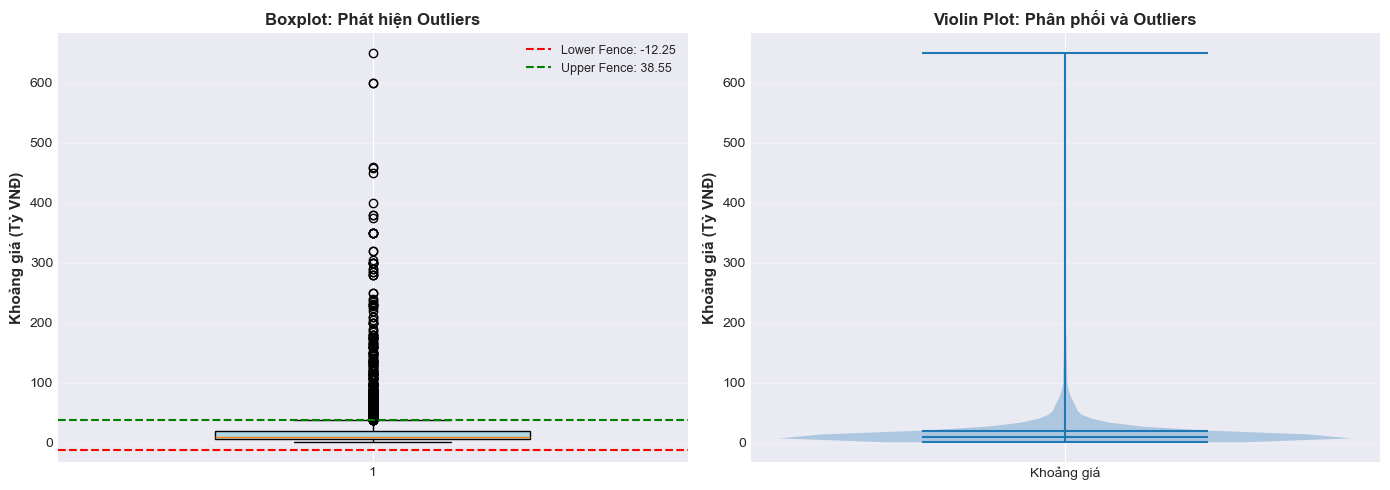


[OUTLIER DETECTION] Phương pháp IQR:
    Statistic    Value
     Q1 (25%)   6.8000
     Q3 (75%)  19.5000
          IQR  12.7000
  Lower Fence -12.2500
  Upper Fence  38.5500
Outlier Count      483
    Outlier %    9.78%

[INSIGHT]
    - Outliers dưới Lower Fence: 0
    - Outliers trên Upper Fence: 483
    - Tổng outliers: 483 (9.78%)


In [ ]:
# CELL 4: Nhận diện Outliers - IQR Method & Visualization
print("\n" + "="*80)
print("PHẦN 4: PHÁT HIỆN VÀ TRỰC QUAN HÓA OUTLIERS")
print("="*80)

# Tính toán IQR
Q1 = target_data.quantile(0.25)
Q3 = target_data.quantile(0.75)
IQR = Q3 - Q1

# Hàng rào (Fences)
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Xác định outliers
outliers = target_data[(target_data < lower_fence) | (target_data > upper_fence)]
outlier_count = len(outliers)
outlier_pct = (outlier_count / len(target_data)) * 100

# Vẽ Boxplot và Violin plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
bp = ax1.boxplot(target_data, vert=True, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightblue')
ax1.set_ylabel(f'{target_col} (Tỷ VNĐ)', fontsize=11, fontweight='bold')
ax1.set_title('Boxplot: Phát hiện Outliers', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=lower_fence, color='r', linestyle='--', linewidth=1.5, label=f'Lower Fence: {lower_fence:.2f}')
ax1.axhline(y=upper_fence, color='g', linestyle='--', linewidth=1.5, label=f'Upper Fence: {upper_fence:.2f}')
ax1.legend(fontsize=9)

# Violin plot
parts = ax2.violinplot(target_data, vert=True, widths=0.5, showmeans=True, showmedians=True)
ax2.set_ylabel(f'{target_col} (Tỷ VNĐ)', fontsize=11, fontweight='bold')
ax2.set_title('Violin Plot: Phân phối và Outliers', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks([1])
ax2.set_xticklabels([target_col])

plt.tight_layout()
plt.show()

# Xuất bảng IQR và outliers
outlier_summary = pd.DataFrame({
    'Statistic': ['Q1 (25%)', 'Q3 (75%)', 'IQR', 'Lower Fence', 'Upper Fence', 'Outlier Count', 'Outlier %'],
    'Value': [f'{Q1:.4f}', f'{Q3:.4f}', f'{IQR:.4f}', f'{lower_fence:.4f}', 
              f'{upper_fence:.4f}', f'{outlier_count}', f'{outlier_pct:.2f}%']
})

print(f"\n[OUTLIER DETECTION] Phương pháp IQR:")
print(outlier_summary.to_string(index=False))

print(f"\n[INSIGHT]")
print(f"    - Outliers dưới Lower Fence: {(target_data < lower_fence).sum()}")
print(f"    - Outliers trên Upper Fence: {(target_data > upper_fence).sum()}")
print(f"    - Tổng outliers: {outlier_count} ({outlier_pct:.2f}%)")

Outliers do các căn có mức giá trăm tỷ đẩy giá thị trường làm biến động sự phân hóa nhưng những căn này ko phải outliers do các lỗi nhập liệu mà do tồn tại những căn được rao bán được coi như siêu biệt thự

In [ ]:
# CELL 5: Geospatial Heatmap - Bản đồ Nhiệt Không gian
import pandas as pd
import numpy as np
import plotly.express as px 

print("\n" + "="*80)
print("PHẦN 5: PHÂN TÍCH KHÔNG GIAN ĐỊA LÝ (GEOSPATIAL HEATMAP)")
print("="*80)

# MẸO: Đọc lại trực tiếp file dữ liệu sạch ban đầu để lấy lại cột Diện tích
df_goc = pd.read_csv(r'D:\DS108\data\1_data_cleaned_train.csv') 

# Lọc và lấy dữ liệu từ file gốc vừa đọc
df_filtered = df_goc[df_goc['Diện tích'] > 0].copy()

# ... (Giữ nguyên đoạn fig = px.scatter bên dưới của bạn, chỉ cần đổi df_filtered ở dòng đầu tiên của px.scatter)
fig = px.scatter(
    df_filtered,
    x='Longitude',
    y='Latitude',
    color='Khoảng giá', # Nếu đây là string/category
    size='Diện tích',
    hover_data=['Diện tích', 'Khoảng giá', 'Số tầng'],
    # Dùng color_discrete_sequence thay cho color_continuous_scale
    color_discrete_sequence=px.colors.qualitative.Set1, 
    title='Bản đồ nhiệt cấu trúc Giá và Diện tích BĐS theo Tọa độ Địa lý',
    labels={
        'Longitude': 'Kinh độ (Longitude)',
        'Latitude': 'Vĩ độ (Latitude)',
        'Khoảng giá': 'Khoảng giá',
        'Diện tích': 'Diện tích (m²)'
    }
)

fig.update_layout(
    width=1100,
    height=700,
    hovermode='closest'
    # Đã bỏ coloraxis_colorbar vì dùng thang màu rời rạc
)

fig.show()

print(f"\n[CHART] Scatter plot vị trí địa lý đã được tạo!")
print(f"    - X: Longitude (Kinh độ)")
print(f"    - Y: Latitude (Vĩ độ)")
print(f"    - Color: Khoảng giá (Xanh=Rẻ, Vàng=Trung bình, Đỏ=Đắt)")
print(f"    - Size: Diện tích (m²)")



PHẦN 5: PHÂN TÍCH KHÔNG GIAN ĐỊA LÝ (GEOSPATIAL HEATMAP)



[CHART] Scatter plot vị trí địa lý đã được tạo!
    - X: Longitude (Kinh độ)
    - Y: Latitude (Vĩ độ)
    - Color: Khoảng giá (Xanh=Rẻ, Vàng=Trung bình, Đỏ=Đắt)
    - Size: Diện tích (m²)


In [ ]:
Phân bố những căn được rao bán theo từng khoảng giá trên bản đồ địa lý có thể cho thấy xu hướng về vị trí và giá cả. Những khu vực có nhiều căn đắt tiền thường tập trung ở trung tâm hoặc
các khu vực phát triển, trong khi những căn rẻ hơn có thể phân bố rộng rãi hơn, bao gồm cả vùng ven hoặc ngoại ô. 


PHẦN 7: PHÂN TÍCH ẢNH HƯỞNG CỦA BIẾN LIÊN TỤC LÊN GIÁ

[✓] Tìm thấy 2 biến liên tục: ['Số tầng', 'Tổng số phòng']


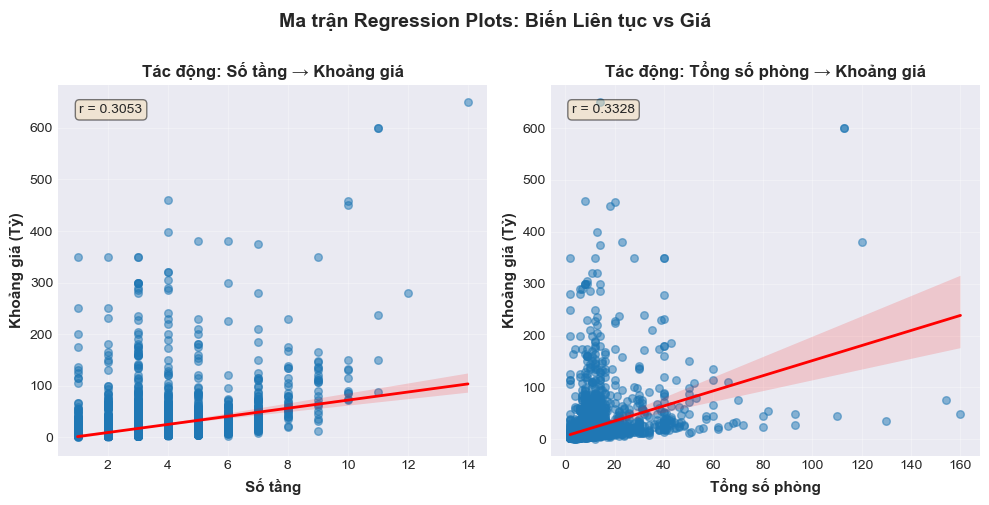


[CORRELATION] Hệ số tương quan Pearson:
     Variable  Correlation
      Số tầng     0.305276
Tổng số phòng     0.332828

[INSIGHT] Diễn giải hệ số tương quan:
    - Số tầng: r = 0.3053 (Vừa phải - Dương)
    - Tổng số phòng: r = 0.3328 (Vừa phải - Dương)


In [ ]:
# CELL 7: Regression Scatter Plots - Ảnh hưởng của biến liên tục
print("\n" + "="*80)
print("PHẦN 7: PHÂN TÍCH ẢNH HƯỞNG CỦA BIẾN LIÊN TỤC LÊN GIÁ")
print("="*80)

# Các biến liên tục cần phân tích
continuous_vars = []
for col in ['Diện tích', 'Số tầng', 'Tổng số phòng']:
    if col in df_eda.columns:
        continuous_vars.append(col)

if len(continuous_vars) > 0:
    print(f"\n[✓] Tìm thấy {len(continuous_vars)} biến liên tục: {continuous_vars}")
    
    # Chuẩn bị dữ liệu
    df_reg = df_eda.dropna(subset=continuous_vars + [target_col]).copy()
    
    # Vẽ ma trận regression plots
    fig, axes = plt.subplots(1, len(continuous_vars), figsize=(5*len(continuous_vars), 5))
    
    if len(continuous_vars) == 1:
        axes = [axes]
    
    correlations = []
    
    for idx, var in enumerate(continuous_vars):
        sns.regplot(
            x=var,
            y=target_col,
            data=df_reg,
            ax=axes[idx],
            scatter_kws={'alpha': 0.5, 's': 30},
            line_kws={'color': 'red', 'linewidth': 2}
        )
        
        axes[idx].set_xlabel(f'{var}', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel(f'{target_col} (Tỷ)', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'Tác động: {var} → {target_col}', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        
        # Tính hệ số tương quan Pearson
        corr = df_reg[var].corr(df_reg[target_col])
        correlations.append({'Variable': var, 'Correlation': corr})
        axes[idx].text(0.05, 0.95, f'r = {corr:.4f}', 
                      transform=axes[idx].transAxes, fontsize=10, 
                      verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Ma trận Regression Plots: Biến Liên tục vs Giá', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # Xuất bảng tương quan
    corr_df = pd.DataFrame(correlations)
    print(f"\n[CORRELATION] Hệ số tương quan Pearson:")
    print(corr_df.to_string(index=False))
    
    print(f"\n[INSIGHT] Diễn giải hệ số tương quan:")
    for idx, row in corr_df.iterrows():
        var = row['Variable']
        corr = row['Correlation']
        strength = "Rất mạnh" if abs(corr) > 0.7 else "Mạnh" if abs(corr) > 0.5 else "Vừa phải" if abs(corr) > 0.3 else "Yếu"
        direction = "Dương" if corr > 0 else "Âm"
        print(f"    - {var}: r = {corr:.4f} ({strength} - {direction})")
else:
    print("[⚠] Không tìm thấy đủ biến liên tục để phân tích")

Giá nhà ảnh hướng có độ tương quan không quá cao vô giá nhà vì tồn tại 3 phân khúc, nhà có ít tầng nhưng lại thuộc dạng biệt phủ hoặc do giá đất quá cao, nhà nhiều tầng thuộc các căn rao bán bất động sản, mức ở giữa thì giá sẽ tăng dựa trên số tầng và phòng -> đây là những căn giá tăng thực sự do 2 biến này


PHẦN 8: PHÂN TÍCH BIẾN PHÂN LOẠI - PHÁP LÝ (SỔ ĐỎ)
[✓] Nạp dữ liệu gốc thành công!
[i] Các cột liên quan đến Pháp lý tìm thấy trong file: ['Pháp lý']
[!] Phát hiện dữ liệu dạng 1 cột phân loại chữ: 'Pháp lý'


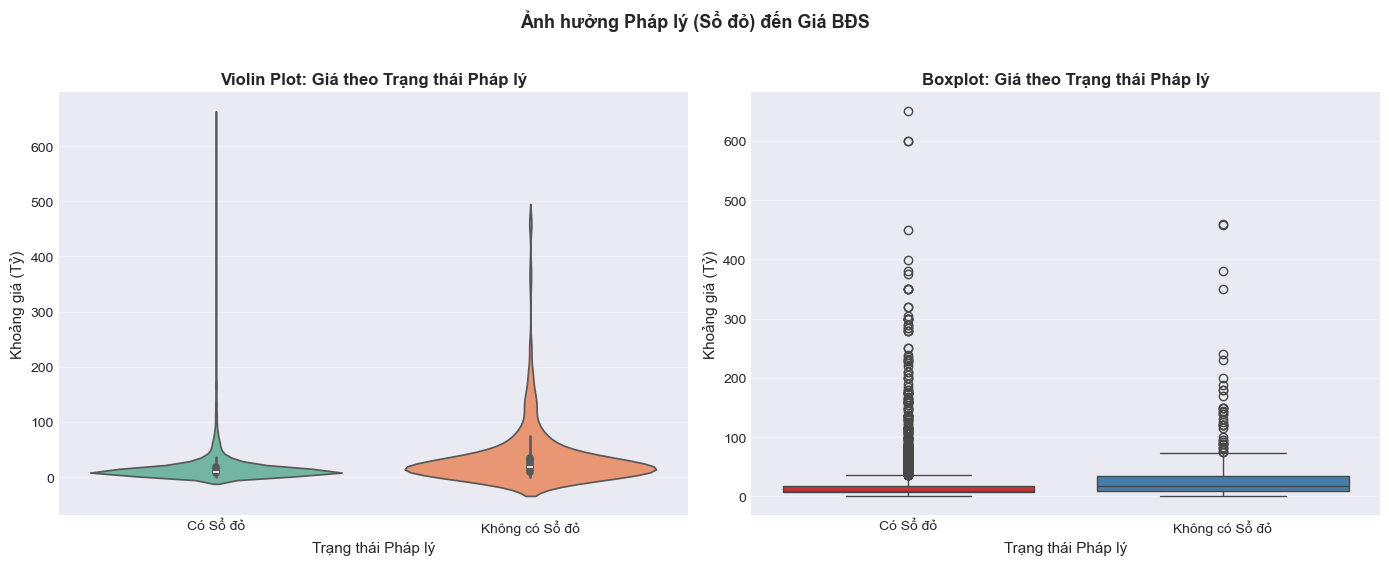


[STATISTICS] Thống kê Giá theo Trạng thái Pháp lý:
                count     mean  median      std   min    max
Legal_Status                                                
Có Sổ đỏ         4594  19.3764     9.5  35.9293  1.03  650.0
Không có Sổ đỏ    343  35.5672    17.5  56.3649  1.02  460.0

[INSIGHT] Kết luận: Nhà CÓ SỔ ĐỎ có giá trung bình rẻ hơn nhà KHÔNG CÓ SỔ ĐỎ là 45.52%


In [ ]:
# CELL 8: Categorical Analysis - Tác động Pháp lý (Sổ đỏ)
# Ép hiển thị đồ họa trực tiếp dưới cell
%matplotlib inline  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("PHẦN 8: PHÂN TÍCH BIẾN PHÂN LOẠI - PHÁP LÝ (SỔ ĐỎ)")
print("="*80)

target_col = 'Khoảng giá'

# Nạp dữ liệu gốc sạch ban đầu từ ổ đĩa
try:
    df_analysis = pd.read_csv(r'D:\DS108\data\1_data_cleaned_train.csv')
    print("[✓] Nạp dữ liệu gốc thành công!")
except FileNotFoundError:
    print("[⚠] Không tìm thấy file ở đường dẫn ổ D. Vui lòng kiểm tra lại đường dẫn.")

# Quét tất cả các cột chứa từ khóa 'Pháp lý'
legal_cols = [col for col in df_analysis.columns if 'Pháp lý' in col or 'phap ly' in col.lower()]
print(f"[i] Các cột liên quan đến Pháp lý tìm thấy trong file: {legal_cols}")

df_legal = df_analysis.copy()
has_data_to_plot = False

# XỬ LÝ DẠNG 1: Nếu dữ liệu chỉ có 1 cột 'Pháp lý' duy nhất chứa text văn bản
if len(legal_cols) == 1:
    col_name = legal_cols[0]
    print(f"[!] Phát hiện dữ liệu dạng 1 cột phân loại chữ: '{col_name}'")
    df_legal['Legal_Status'] = df_legal[col_name].astype(str).str.strip()
    
    # Chuẩn hóa text thành 2 nhóm lớn để so sánh
    df_legal.loc[df_legal['Legal_Status'].str.contains('Sổ đỏ|Sổ hồng|Đã có|Có sổ', case=False, na=False), 'Legal_Status'] = 'Có Sổ đỏ'
    df_legal.loc[df_legal['Legal_Status'].str.contains('Không|Chưa|Hợp đồng|Giấy tay', case=False, na=False), 'Legal_Status'] = 'Không có Sổ đỏ'
    
    # Lọc bỏ các dòng ngoại lai không thuộc 2 nhóm trên
    df_legal = df_legal[df_legal['Legal_Status'].isin(['Có Sổ đỏ', 'Không có Sổ đỏ'])]
    if len(df_legal) > 0:
        has_data_to_plot = True

# XỬ LÝ DẠNG 2: Nếu dữ liệu đã được mã hóa thành nhiều cột One-Hot (0 và 1)
elif len(legal_cols) >= 2:
    print("[!] Phát hiện dữ liệu dạng nhiều cột mã hóa One-Hot.")
    df_legal['Legal_Status'] = 'Unknown'
    if 'Pháp lý_Sổ đỏ' in legal_cols:
        df_legal.loc[df_legal['Pháp lý_Sổ đỏ'] == 1, 'Legal_Status'] = 'Có Sổ đỏ'
    if 'Pháp lý_không có' in legal_cols:
        df_legal.loc[df_legal['Pháp lý_không có'] == 1, 'Legal_Status'] = 'Không có Sổ đỏ'
        
    df_legal = df_legal[df_legal['Legal_Status'] != 'Unknown']
    if len(df_legal) > 0:
        has_data_to_plot = True

# TIẾN HÀNH VẼ BIỂU ĐỒ NẾU THỎA MÃN DỮ LIỆU
if has_data_to_plot:
    df_legal = df_legal.dropna(subset=[target_col])
    
    # Khởi tạo khung hình với kích thước rõ ràng
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    
    # 1. Vẽ Violin Plot
    sns.violinplot(
        data=df_legal,
        x='Legal_Status',
        y=target_col,
        ax=axes[0],
        palette='Set2'
    )
    axes[0].set_title('Violin Plot: Giá theo Trạng thái Pháp lý', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Trạng thái Pháp lý', fontsize=11)
    axes[0].set_ylabel(f'{target_col} (Tỷ)', fontsize=11)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # 2. Vẽ Boxplot
    sns.boxplot(
        data=df_legal,
        x='Legal_Status',
        y=target_col,
        ax=axes[1],
        palette='Set1'
    )
    axes[1].set_title('Boxplot: Giá theo Trạng thái Pháp lý', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Trạng thái Pháp lý', fontsize=11)
    axes[1].set_ylabel(f'{target_col} (Tỷ)', fontsize=11)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Ảnh hưởng Pháp lý (Sổ đỏ) đến Giá BĐS', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Lệnh ép buộc hiển thị trực tiếp đồ họa ra màn hình
    plt.show()
    
    # In thông tin thống kê số liệu xuống dưới hình
    legal_stats = df_legal.groupby('Legal_Status')[target_col].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(4)
    print(f"\n[STATISTICS] Thống kê Giá theo Trạng thái Pháp lý:")
    print(legal_stats)
    
    try:
        mean_co_so = legal_stats.loc['Có Sổ đỏ', 'mean']
        mean_khong_so = legal_stats.loc['Không có Sổ đỏ', 'mean']
        pct_diff = ((mean_co_so - mean_khong_so) / mean_khong_so * 100) if mean_khong_so != 0 else 0
        trang_thai_sanh = "đắt hơn" if pct_diff > 0 else "rẻ hơn"
        print(f"\n[INSIGHT] Kết luận: Nhà CÓ SỔ ĐỎ có giá trung bình {trang_thai_sanh} nhà KHÔNG CÓ SỔ ĐỎ là {abs(pct_diff):.2f}%")
    except KeyError:
        pass
else:
    print("[⚠] Không tìm thấy dòng dữ liệu nào khớp với nhóm 'Có Sổ đỏ' hoặc 'Không có Sổ đỏ' để phân tích vẽ hình.")

In [ ]:
# CELL 10: Text Cleaning & Keyword Extraction - Phân tích Từ khóa từ Mô tả
print("\n" + "="*80)
print("PHẦN 10: XỬ LÝ NGÔN NGỮ TỰ NHIÊN - TRÍCH XUẤT TỪ KHÓA")
print("="*80)

# Vietnamese stopwords
vietnamese_stopwords = {
    'và', 'hay', 'hoặc', 'cho', 'của', 'là', 'cái', 'những', 'được',
    'à', 'ah', 'ơi', 'thôi', 'cũng', 'vì', 'tại', 'nên', 'như', 'nhưng',
    'mà', 'hết', 'sau', 'trước', 'trên', 'dưới', 'bên', 'cạnh', 'giữa',
    'ngoài', 'trong', 'nó', 'này', 'kia', 'đó', 'đây', 'nào', 'một',
    'hai', 'ba', 'bốn', 'năm', 'sáu', 'bảy', 'tám', 'chín', 'mười', 'a', 'an'
}

def clean_text(text):
    """Hàm làm sạch văn bản"""
    if pd.isna(text) or text == '':
        return ''
    text = str(text).lower()
    # Loại bỏ số
    text = re.sub(r'[0-9]+', '', text)
    # Loại bỏ ký tự đặc biệt
    text = re.sub(r'[^\w\s]', '', text)
    # Tách từ
    words = text.split()
    # Loại bỏ stopwords và từ quá ngắn
    words = [w for w in words if w not in vietnamese_stopwords and len(w) > 2]
    return ' '.join(words)

# Tìm cột Mô tả
description_col = None
for col in df_eda.columns:
    if 'mô tả' in col.lower() or 'description' in col.lower() or 'desc' in col.lower():
        description_col = col
        break

if description_col is None:
    print("[⚠] Không tìm thấy cột Mô tả. Tạo dữ liệu demo...")
    descriptions = [
        "hẻm xe hơi mặt tiền sổ hồng", "nhà thô trống cần tiền gấp", "shophouse kinh doanh mặt phố",
        "ngộp cắt lỗ bán gấp hẻm ô tô", "sổ đỏ mặt tiền kinh doanh tốt", "hẻm xe hơi rộng thoáng",
        "nhà mới đẹp full nội thất cao cấp", "vị trí đắc địa mặt phố kinh doanh", "ngộp giá rẻ cần bán gấp"
    ] * int(np.ceil(len(df_eda) / 9))
    df_eda['Mo_ta'] = descriptions[:len(df_eda)]
    description_col = 'Mo_ta'

print(f"\n[PROCESS] Làm sạch văn bản từ cột: {description_col}")
df_eda['text_cleaned'] = df_eda[description_col].apply(clean_text)

# Tách và đếm từ
all_text = ' '.join(df_eda['text_cleaned'].values)
words = all_text.split()

from collections import Counter
word_freq = Counter(words)

# Top 30 từ khóa
top_30_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:30]
top_30_df = pd.DataFrame(top_30_words, columns=['Keyword', 'Frequency'])
top_30_df['Frequency_%'] = (top_30_df['Frequency'] / top_30_df['Frequency'].sum() * 100).round(2)

print(f"\n[KEYWORDS] Top 30 Từ khóa xuất hiện nhiều nhất:")
print(top_30_df.to_string(index=False))

print(f"\n[STATISTICS] Thống kê văn bản làm sạch:")
print(f"    - Tổng từ tokenized: {len(words)}")
print(f"    - Số từ duy nhất: {len(word_freq)}")
print(f"    - Từ xuất hiện nhiều nhất: '{top_30_words[0][0]}' ({top_30_words[0][1]} lần)")


PHẦN 10: XỬ LÝ NGÔN NGỮ TỰ NHIÊN - TRÍCH XUẤT TỪ KHÓA
[⚠] Không tìm thấy cột Mô tả. Tạo dữ liệu demo...

[PROCESS] Làm sạch văn bản từ cột: Mo_ta

[KEYWORDS] Top 30 Từ khóa xuất hiện nhiều nhất:
  Keyword  Frequency  Frequency_%
      mặt       2195         8.17
     tiền       1647         6.13
      hẻm       1646         6.12
      gấp       1646         6.12
     kinh       1646         6.12
    doanh       1646         6.12
      hơi       1097         4.08
      nhà       1097         4.08
      cần       1097         4.08
      phố       1097         4.08
     ngộp       1097         4.08
      bán       1097         4.08
     hồng        549         2.04
      thô        549         2.04
    trống        549         2.04
shophouse        549         2.04
      cắt        549         2.04
      tốt        549         2.04
     rộng        548         2.04
   thoáng        548         2.04
      mới        548         2.04
      đẹp        548         2.04
     full        548  


PHẦN 13: TINH GỌN MÔ HÌNH - FEATURE ENGINEERING & PCA DIMENSION REDUCTION
[✓] Đã gộp và loại bỏ 'Latitude', 'Longitude' → 'khoang_cach_trung_tam'
[✓] Đã dùng PCA gộp 4 biến tỉ lệ quy hoạch thành 'chi_so_ha_tang_do_thi' (Giữ lại 33.51% thông tin gốc)
[✓] Đã mã hóa biến phân loại: 'Pháp lý' → 'Pháp lý_encoded'
[✓] Đã mã hóa biến phân loại: 'Nội thất' → 'Nội thất_encoded'
[✓] Đã mã hóa biến phân loại: 'Loại đường vào' → 'Loại đường vào_encoded'


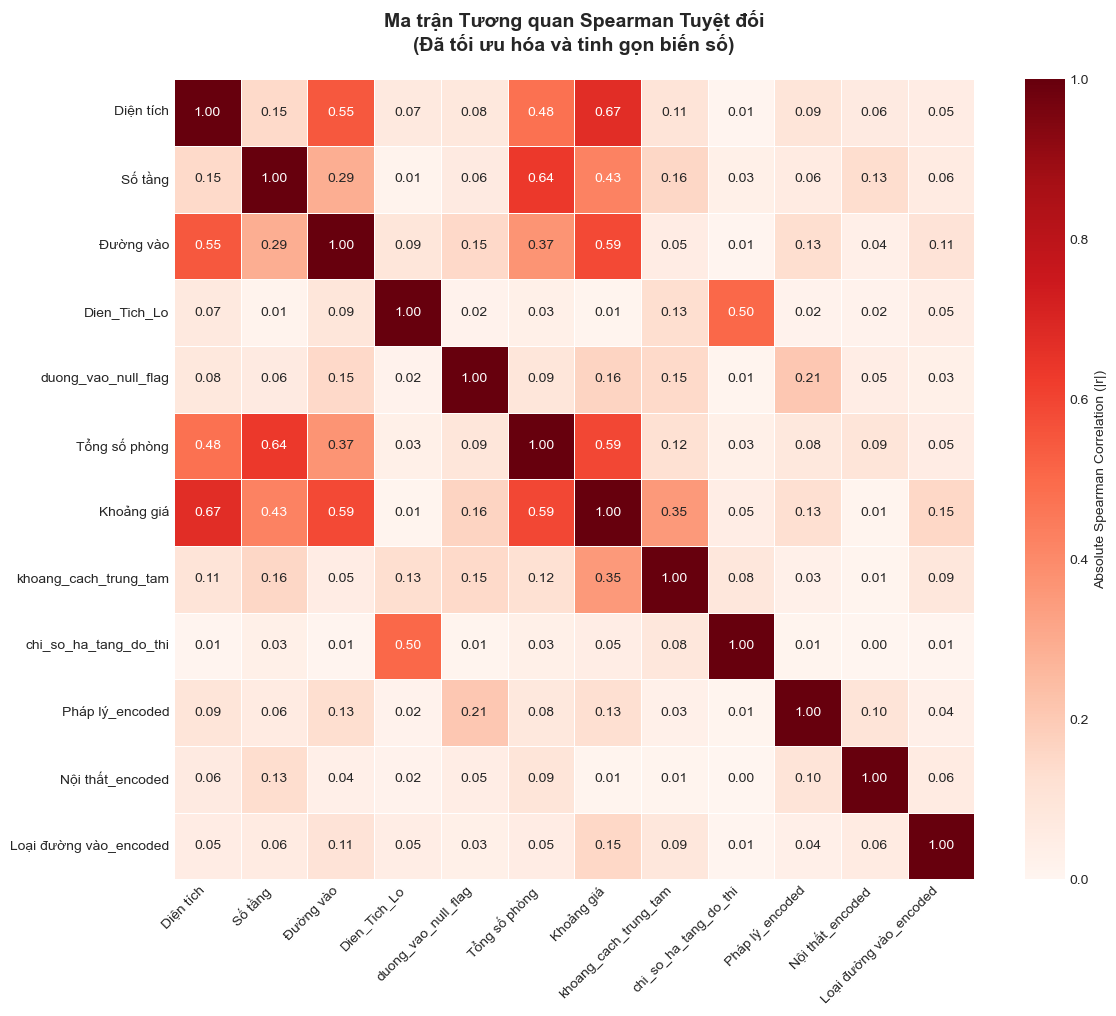


[TARGET CORRELATION] Bảng xếp hạng ảnh hưởng đến biến mục tiêu 'Khoảng giá':
Khoảng giá                1.000000
Diện tích                 0.672256
Tổng số phòng             0.589930
Đường vào                 0.586549
Số tầng                   0.425235
khoang_cach_trung_tam     0.353431
duong_vao_null_flag       0.164455
Loại đường vào_encoded    0.153966
Pháp lý_encoded           0.126701
chi_so_ha_tang_do_thi     0.050231
Dien_Tich_Lo              0.009332
Nội thất_encoded          0.008639


In [ ]:
# CELL 13: Advanced Feature Engineering, Dimension Reduction (PCA) & Spearman Heatmap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("\n" + "="*80)
print("PHẦN 13: TINH GỌN MÔ HÌNH - FEATURE ENGINEERING & PCA DIMENSION REDUCTION")
print("="*80)

# Tạo bản sao dữ liệu để phân tích
df_analysis = df_eda.copy()

# -------------------------------------------------------------------------
# BƯỚC 1: GỘP KINH ĐỘ & VĨ ĐỘ THÀNH KHOẢNG CÁCH TRUNG TÂM
# -------------------------------------------------------------------------
LAT_CENTER, LON_CENTER = 10.7760, 106.7011

def calculate_haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371  # Bán kính Trái Đất (km)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(delta_phi := lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    return r * (2 * np.arcsin(np.sqrt(a)))

df_analysis['khoang_cach_trung_tam'] = calculate_haversine_distance(
    df_analysis['Latitude'], df_analysis['Longitude'], LAT_CENTER, LON_CENTER
)
# Xóa bỏ ngay 2 biến gốc
df_analysis = df_analysis.drop(columns=['Latitude', 'Longitude'], errors='ignore')
print("[✓] Đã gộp và loại bỏ 'Latitude', 'Longitude' → 'khoang_cach_trung_tam'")


# -------------------------------------------------------------------------
# BƯỚC 2: DÙNG PCA GỘP 4 BIẾN TỈ LỆ QUY HOẠCH THÀNH 1 BIẾN DUY NHẤT
# -------------------------------------------------------------------------
ratio_cols = ['Ty_Le_Giao_Thong', 'Ty_Le_Cong_Cong_CX', 'Ty_Le_Khac', 'Ty_Le_Dat_O']

# Kiểm tra nếu đủ 4 cột thì tiến hành gộp
if all(col in df_analysis.columns for col in ratio_cols):
    # Điền giá trị thiếu bằng 0 hoặc median trước khi chạy PCA
    ratio_data = df_analysis[ratio_cols].fillna(0)
    
    # Chuẩn hóa dữ liệu (Standardization) là bắt buộc trước khi chạy PCA
    scaler = StandardScaler()
    ratio_scaled = scaler.fit_transform(ratio_data)
    
    # Khởi tạo PCA để giữ lại 1 thành phần chính duy nhất đại diện cho hạ tầng
    pca = PCA(n_components=1, random_state=42)
    df_analysis['chi_so_ha_tang_do_thi'] = pca.fit_transform(ratio_scaled)
    
    # Giải thích lượng thông tin giữ lại được
    explained_variance = pca.explained_variance_ratio_[0] * 100
    print(f"[✓] Đã dùng PCA gộp 4 biến tỉ lệ quy hoạch thành 'chi_so_ha_tang_do_thi' (Giữ lại {explained_variance:.2f}% thông tin gốc)")
    
    # Xóa bỏ 4 biến tỉ lệ gốc để ma trận không bị loãng
    df_analysis = df_analysis.drop(columns=ratio_cols)
else:
    print("[⚠] Không tìm thấy đủ 4 cột tỉ lệ để tiến hành gộp PCA.")


# -------------------------------------------------------------------------
# BƯỚC 3: MÃ HÓA CÁC BIẾN PHÂN LOẠI (BAO GỒM NỘI THẤT VÀ PHÁP LÝ)
# -------------------------------------------------------------------------
categorical_cols_to_include = ['Pháp lý', 'Nội thất', 'Loại đường vào']

for col in categorical_cols_to_include:
    if col in df_analysis.columns:
        df_analysis[col] = df_analysis[col].fillna('Chưa xác định')
        le = LabelEncoder()
        df_analysis[f'{col}_encoded'] = le.fit_transform(df_analysis[col].astype(str))
        print(f"[✓] Đã mã hóa biến phân loại: '{col}' → '{col}_encoded'")


# -------------------------------------------------------------------------
# BƯỚC 4: TÍNH MA TRẬN TƯƠNG QUAN SPEARMAN GỌN GÀNG (0 ĐẾN 1)
# -------------------------------------------------------------------------
numeric_df = df_analysis.select_dtypes(include=[np.number])
numeric_df_imputed = numeric_df.fillna(numeric_df.median())

# Tính trị tuyệt đối ma trận Spearman
corr_matrix_abs = numeric_df_imputed.corr(method='spearman').abs()


# -------------------------------------------------------------------------
# BƯỚC 5: VẼ HEATMAP MỚI - SIÊU TINH GỌN
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix_abs,
    annot=True,
    fmt='.2f',
    cmap='Reds',
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Absolute Spearman Correlation (|r|)'},
    ax=ax,
    vmin=0,
    vmax=1
)

ax.set_title('Ma trận Tương quan Spearman Tuyệt đối\n(Đã tối ưu hóa và tinh gọn biến số)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# BƯỚC 6: XẾP HẠNG ẢNH HƯỞNG ĐẾN BIẾN MỤC TIÊU
# -------------------------------------------------------------------------
target_col = 'Khoảng giá'

print(f"\n[TARGET CORRELATION] Bảng xếp hạng ảnh hưởng đến biến mục tiêu '{target_col}':")
if target_col in corr_matrix_abs.columns:
    target_corr = corr_matrix_abs[target_col].sort_values(ascending=False)
    print(target_corr.to_string())
else:
    print(f"[⚠] Không tìm thấy cột mục tiêu '{target_col}'")

In [ ]:
# CELL 14: VIF Analysis - Variance Inflation Factor
print("\n" + "="*80)
print("PHẦN 14: ĐO LƯỜNG ĐA CỘNG TUYẾN - VIF ANALYSIS")
print("="*80)

# Chuẩn bị dữ liệu cho tính VIF
vif_df = numeric_df.dropna()

if len(vif_df) > 0 and len(vif_df.columns) > 1:
    print(f"\n[PROCESS] Tính VIF cho {len(vif_df.columns)} biến số")
    
    # Tính VIF
    vif_results = []
    for i, col in enumerate(vif_df.columns):
        try:
            vif_value = variance_inflation_factor(vif_df.values, i)
            vif_results.append({
                'Feature': col,
                'VIF_Value': vif_value
            })
        except:
            vif_results.append({
                'Feature': col,
                'VIF_Value': np.inf
            })
    
    vif_df_result = pd.DataFrame(vif_results).sort_values('VIF_Value', ascending=False)
    
    print(f"\n[VIF RESULTS] Chỉ số VIF cho tất cả biến:")
    print(vif_df_result.to_string(index=False))
    
    # Bộ lọc tự động cảnh báo
    print(f"\n[MULTICOLLINEARITY WARNINGS]")
    
    critical_vars = vif_df_result[vif_df_result['VIF_Value'] > 10]
    warning_vars = vif_df_result[(vif_df_result['VIF_Value'] > 5) & (vif_df_result['VIF_Value'] <= 10)]
    normal_vars = vif_df_result[vif_df_result['VIF_Value'] <= 5]
    
    if len(critical_vars) > 0:
        print(f"\n🔴 [CRITICAL] {len(critical_vars)} biến có VIF > 10 (ĐẠI CẢNH BÁO):")
        for idx, row in critical_vars.iterrows():
            print(f"    ❌ {row['Feature']}: VIF = {row['VIF_Value']:.2f} (Đa cộng tuyến CỰC KỲ NẶNG)")
    
    if len(warning_vars) > 0:
        print(f"\n🟠 [WARNING] {len(warning_vars)} biến có 5 < VIF ≤ 10 (CẢN THẬN):")
        for idx, row in warning_vars.iterrows():
            print(f"    ⚠️  {row['Feature']}: VIF = {row['VIF_Value']:.2f} (Đa cộng tuyến đáng chú ý)")
    
    if len(normal_vars) > 0:
        print(f"\n🟢 [OK] {len(normal_vars)} biến có VIF ≤ 5 (Bình thường):")
        ok_count = len([v for v in normal_vars['VIF_Value'] if v <= 5])
        print(f"    ✓ {ok_count} biến không có vấn đề đa cộng tuyến")
    
    # Tóm tắt khuyến nghị
    print(f"\n[RECOMMENDATIONS]")
    if len(critical_vars) > 0:
        print(f"    1. ❌ XÓA hoặc LOẠI BỎ ngay {len(critical_vars)} biến với VIF > 10")
        print(f"       └─ Các biến này có đa cộng tuyến quá nặng, làm hỏng mô hình")
    
    if len(warning_vars) > 0:
        print(f"    2. ⚠️  XEM XÉT loại bỏ {len(warning_vars)} biến với 5 < VIF ≤ 10")
        print(f"       └─ Cân nhắc giữ hay loại bỏ dựa vào tầm quan trọng của biến")
    
    print(f"    3. ✓ GIỮ {len(normal_vars)} biến với VIF ≤ 5 (không vấn đề)")

else:
    print("[⚠] Không đủ dữ liệu hoặc chỉ có 1 biến để tính VIF")


PHẦN 14: ĐO LƯỜNG ĐA CỘNG TUYẾN - VIF ANALYSIS

[PROCESS] Tính VIF cho 16 biến số

[VIF RESULTS] Chỉ số VIF cho tất cả biến:
            Feature    VIF_Value
           Latitude 62976.968752
          Longitude 62463.111326
        Ty_Le_Dat_O    24.927588
   Ty_Le_Giao_Thong    22.302815
            Số tầng     9.049932
 Ty_Le_Cong_Cong_CX     6.484058
         Ty_Le_Khac     4.852917
          Đường vào     3.722491
      Tổng số phòng     3.096530
     has_kinh doanh     2.275780
     has_hẻm xe hơi     2.255808
         Khoảng giá     1.730896
duong_vao_null_flag     1.652247
       has_mặt tiền     1.502165
       Dien_Tich_Lo     1.118800
    has_ô tô đỗ cửa          NaN

[MULTICOLLINEARITY WARNINGS]

🔴 [CRITICAL] 4 biến có VIF > 10 (ĐẠI CẢNH BÁO):
    ❌ Latitude: VIF = 62976.97 (Đa cộng tuyến CỰC KỲ NẶNG)
    ❌ Longitude: VIF = 62463.11 (Đa cộng tuyến CỰC KỲ NẶNG)
    ❌ Ty_Le_Dat_O: VIF = 24.93 (Đa cộng tuyến CỰC KỲ NẶNG)
    ❌ Ty_Le_Giao_Thong: VIF = 22.30 (Đa cộng tuyến CỰC K


PHẦN 16: PHÂN TÍCH TÁC ĐỘNG TẤT CẢ BIẾN SỐ ĐẾN GIÁ (KHOẢNG GIÁ)

[✓] Phân tích 12 biến số
    Các biến: ['Diện tích', 'Số tầng', 'Đường vào', 'Latitude', 'Longitude', 'Dien_Tich_Lo', 'duong_vao_null_flag', 'Ty_Le_Giao_Thong', 'Ty_Le_Cong_Cong_CX', 'Ty_Le_Khac']...

[BẢNG TÓMSỦT] TÁC ĐỘNG CỦA TẤT CẢ BIẾN SỐ:
            Feature  Correlation  Price_Ratio_Q4_Q1  Impact_%  Count
0         Diện tích       0.5429             4.8229    382.29   4937
2         Đường vào       0.3934             5.5721    457.21   4937
8     Tổng số phòng       0.3328             3.7886    278.86   4937
1           Số tầng       0.3053             2.7604    176.04   4937
5      Dien_Tich_Lo       0.0748             1.3088     30.88   3871
7       Ty_Le_Dat_O      -0.0680             0.6698    -33.02   3864
6  Ty_Le_Giao_Thong       0.0429             1.1669     16.69   3864
3          Latitude       0.0089             0.7523    -24.77   4937
4         Longitude       0.0071             1.5448     54.48   4937


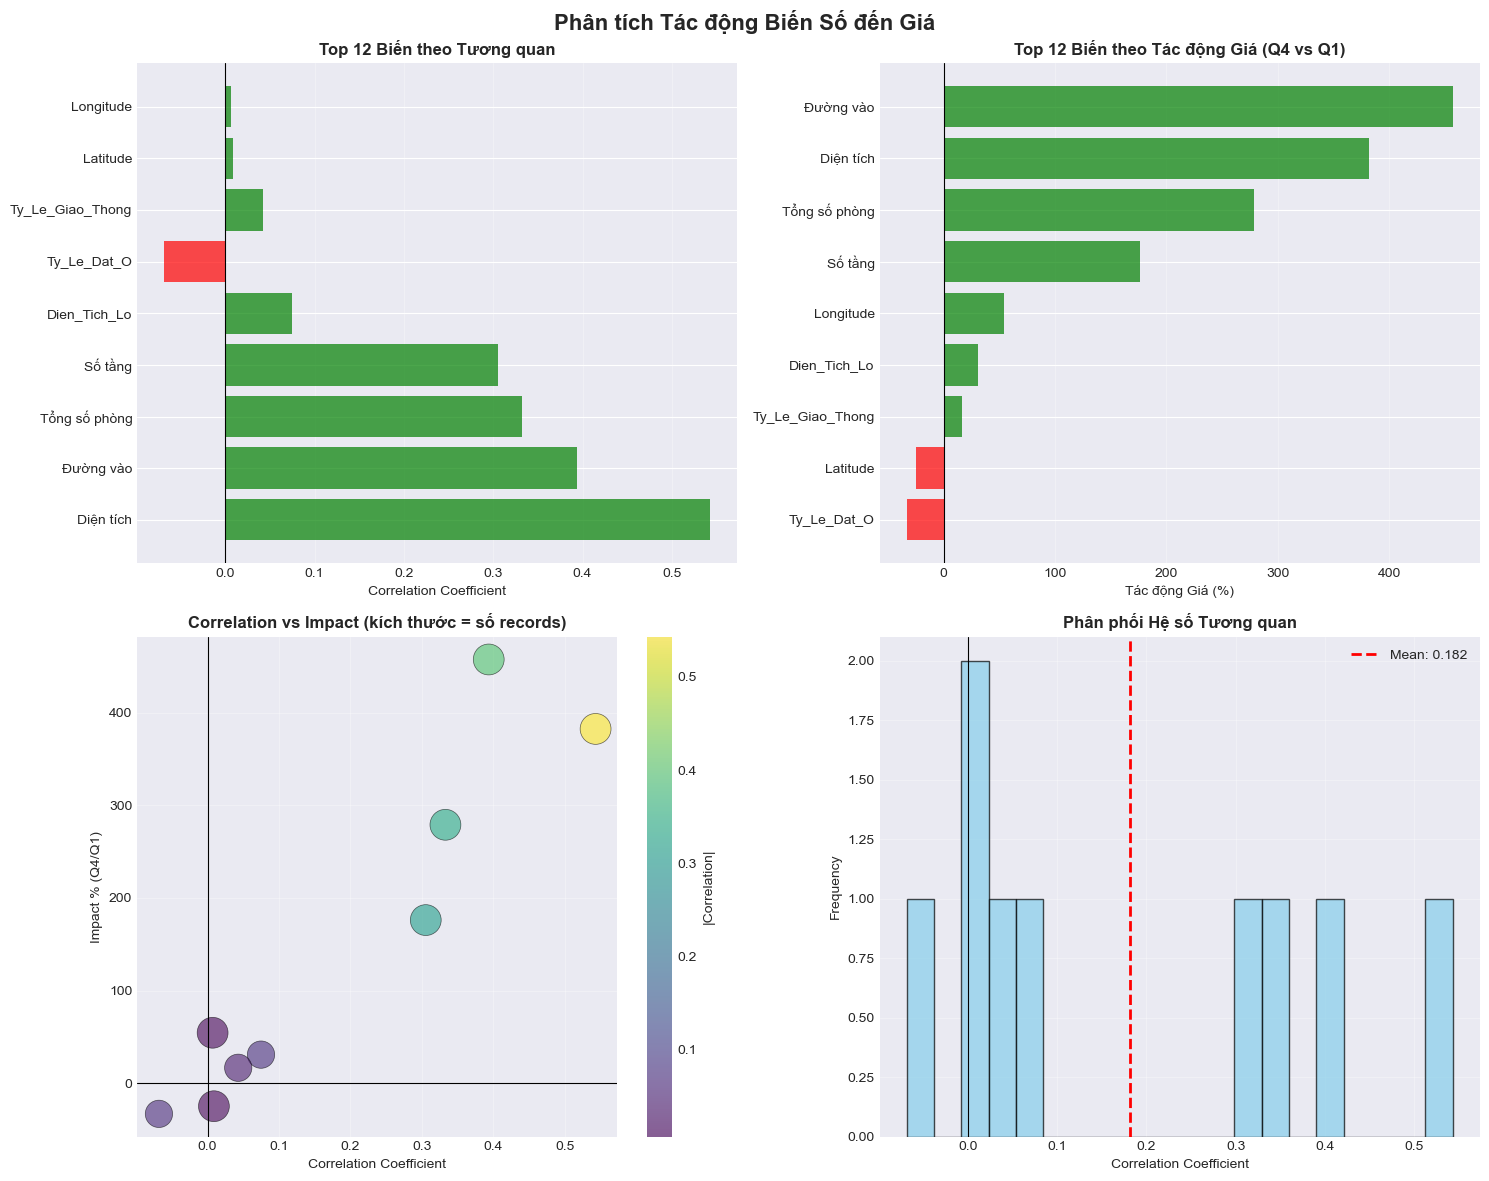


[THỐNG KÊ] Tổng hợp Tương quan:
    - Trung bình: 0.1822
    - Median: 0.0748
    - Std Dev: 0.2141
    - Min: -0.0680
    - Max: 0.5429

[CHI TIẾT] Top 15 Biến có Tác động mạnh nhất:
         Feature  Correlation  Price_Ratio_Q4_Q1  Impact_%  Price_Avg  Price_Min  Price_Max  Count
       Diện tích       0.5429             4.8229    382.29  20.501235       1.02      650.0   4937
       Đường vào       0.3934             5.5721    457.21  20.501235       1.02      650.0   4937
   Tổng số phòng       0.3328             3.7886    278.86  20.501235       1.02      650.0   4937
         Số tầng       0.3053             2.7604    176.04  20.501235       1.02      650.0   4937
    Dien_Tich_Lo       0.0748             1.3088     30.88  20.473013       1.03      650.0   3871
     Ty_Le_Dat_O      -0.0680             0.6698    -33.02  20.500029       1.03      650.0   3864
Ty_Le_Giao_Thong       0.0429             1.1669     16.69  20.500029       1.03      650.0   3864
        Latitude       

In [ ]:

# ============================================================================
# PHẦN 16: PHÂN TÍCH TOÀN DIỆN TÁC ĐỘNG CỦA TẤT CẢ BIẾN SỐ ĐẾN LABEL
# ============================================================================

print("\n" + "="*80)
print("PHẦN 16: PHÂN TÍCH TÁC ĐỘNG TẤT CẢ BIẾN SỐ ĐẾN GIÁ (KHOẢNG GIÁ)")
print("="*80)

# Xác định target
target_col = 'Khoảng giá'
target_data = df_eda[target_col]

# Lấy danh sách tất cả các biến số
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != target_col]

print(f"\n[✓] Phân tích {len(numeric_cols)} biến số")
print(f"    Các biến: {numeric_cols[:10]}..." if len(numeric_cols) > 10 else f"    Các biến: {numeric_cols}")

# Tạo bảng tóm tắt tác động của tất cả biến số
impact_summary_numeric = []

for col in numeric_cols:
    try:
        # Loại bỏ NaN
        valid_mask = df_eda[col].notna() & df_eda[target_col].notna()
        col_data = df_eda.loc[valid_mask, col]
        target_valid = df_eda.loc[valid_mask, target_col]
        
        # Tính toán thống kê
        correlation = col_data.corr(target_valid)
        
        # Tìm quartiles
        q1, q2, q3 = col_data.quantile([0.25, 0.5, 0.75])
        
        # Giá trung bình theo quartiles
        quartile_labels = pd.qcut(col_data, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
        price_by_quartile = target_valid.groupby(quartile_labels).agg(['mean', 'median', 'count'])
        
        # Tính tỷ lệ giá Q4/Q1 để thấy tác động
        if len(price_by_quartile) >= 2:
            price_ratio = price_by_quartile.loc['Q4', 'mean'] / price_by_quartile.loc['Q1', 'mean'] if price_by_quartile.loc['Q1', 'mean'] > 0 else 0
            price_diff_pct = (price_ratio - 1) * 100
        else:
            price_ratio = 0
            price_diff_pct = 0
        
        impact_summary_numeric.append({
            'Feature': col,
            'Count': col_data.count(),
            'Min': col_data.min(),
            'Max': col_data.max(),
            'Mean': col_data.mean(),
            'Correlation': round(correlation, 4),
            'Price_Avg': target_valid.mean(),
            'Price_Min': target_valid.min(),
            'Price_Max': target_valid.max(),
            'Price_Ratio_Q4_Q1': round(price_ratio, 4),
            'Impact_%': round(price_diff_pct, 2)
        })
    except Exception as e:
        continue

impact_df = pd.DataFrame(impact_summary_numeric)
# Sắp xếp theo tương quan tuyệt đối
impact_df['Abs_Correlation'] = impact_df['Correlation'].abs()
impact_df = impact_df.sort_values('Abs_Correlation', ascending=False)

print("\n[BẢNG TÓMSỦT] TÁC ĐỘNG CỦA TẤT CẢ BIẾN SỐ:")
print(impact_df[['Feature', 'Correlation', 'Price_Ratio_Q4_Q1', 'Impact_%', 'Count']].to_string())

# Visualize tương quan
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Phân tích Tác động Biến Số đến Giá', fontsize=16, fontweight='bold')

# 1. Top 12 biến theo tương quan
ax = axes[0, 0]
top_corr = impact_df.head(12)
colors_corr = ['green' if x > 0 else 'red' for x in top_corr['Correlation']]
ax.barh(range(len(top_corr)), top_corr['Correlation'], color=colors_corr, alpha=0.7)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr['Feature'])
ax.set_xlabel('Correlation Coefficient')
ax.set_title('Top 12 Biến theo Tương quan', fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

# 2. Top 12 biến theo tác động giá (Impact %)
ax = axes[0, 1]
impact_top = impact_df.head(12).sort_values('Impact_%', ascending=True)
colors_impact = ['green' if x > 0 else 'red' for x in impact_top['Impact_%']]
ax.barh(range(len(impact_top)), impact_top['Impact_%'], color=colors_impact, alpha=0.7)
ax.set_yticks(range(len(impact_top)))
ax.set_yticklabels(impact_top['Feature'])
ax.set_xlabel('Tác động Giá (%)')
ax.set_title('Top 12 Biến theo Tác động Giá (Q4 vs Q1)', fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

# 3. Scatter plot: Correlation vs Impact
ax = axes[1, 0]
scatter = ax.scatter(impact_df['Correlation'], impact_df['Impact_%'], 
                     s=impact_df['Count']/10, alpha=0.6, c=impact_df['Abs_Correlation'], 
                     cmap='viridis', edgecolors='black', linewidth=0.5)
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Impact % (Q4/Q1)')
ax.set_title('Correlation vs Impact (kích thước = số records)', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.colorbar(scatter, ax=ax, label='|Correlation|')

# 4. Distribution của tương quan
ax = axes[1, 1]
ax.hist(impact_df['Correlation'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(x=impact_df['Correlation'].mean(), color='red', linestyle='--', 
           label=f'Mean: {impact_df["Correlation"].mean():.3f}', linewidth=2)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Frequency')
ax.set_title('Phân phối Hệ số Tương quan', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[THỐNG KÊ] Tổng hợp Tương quan:")
print(f"    - Trung bình: {impact_df['Correlation'].mean():.4f}")
print(f"    - Median: {impact_df['Correlation'].median():.4f}")
print(f"    - Std Dev: {impact_df['Correlation'].std():.4f}")
print(f"    - Min: {impact_df['Correlation'].min():.4f}")
print(f"    - Max: {impact_df['Correlation'].max():.4f}")

# Tạo bảng chi tiết cho top 15 biến
print("\n[CHI TIẾT] Top 15 Biến có Tác động mạnh nhất:")
detailed_cols = ['Feature', 'Correlation', 'Price_Ratio_Q4_Q1', 'Impact_%', 
                 'Price_Avg', 'Price_Min', 'Price_Max', 'Count']
print(impact_df[detailed_cols].head(15).to_string(index=False))



PHẦN 17: PHÂN TÍCH TÁC ĐỘNG TẤT CẢ BIẾN PHÂN LOẠI ĐẾN GIÁ

[✓] Phân tích 6 biến phân loại
    Các biến: ['Pháp lý', 'Nội thất', 'Loại đường vào', 'Quan_Huyen', 'Phuong_Xa', 'Đường_Từ_Địa_Chỉ']

[BẢNG TÓMSỦT] TÁC ĐỘNG CỦA TẤT CẢ BIẾN PHÂN LOẠI:
         Feature  Unique_Values  Impact_%  Price_Ratio_Max_Min  Chi2_Score  Count
Đường_Từ_Địa_Chỉ            930  36056.04             361.5604      0.7728   4937
       Phuong_Xa            150  15130.17             152.3017      0.3706   4937
      Quan_Huyen             24   2943.51              30.4351      0.2650   4937
  Loại đường vào              4    215.74               3.1574      0.0608   4937
         Pháp lý              3     83.59               1.8359      0.0164   4937
        Nội thất              4     72.63               1.7263      0.0302   4937


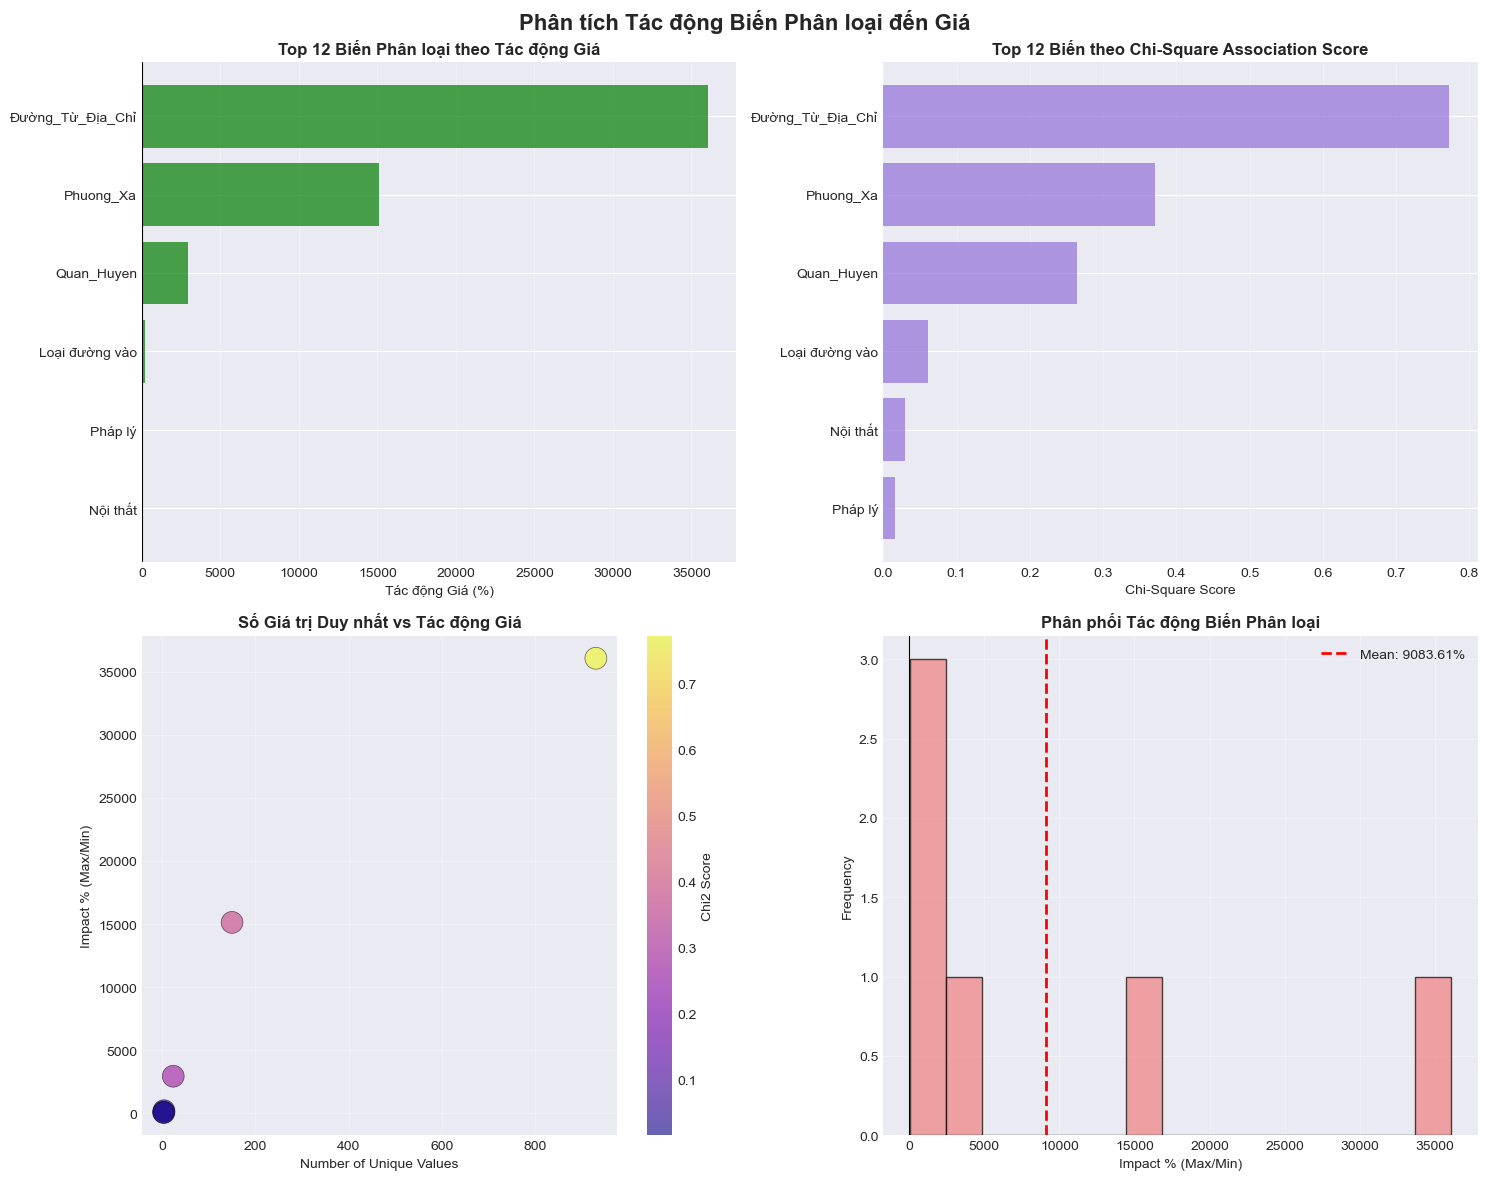


[THỐNG KÊ] Tổng hợp Biến Phân loại:
    - Trung bình Impact %: 9083.61%
    - Median Impact %: 1579.62%
    - Tác động cao nhất: 36056.04%
    - Tác động thấp nhất: 72.63%

[CHI TIẾT] Top 12 Biến Phân loại có Tác động mạnh nhất:
         Feature  Unique_Values  Impact_%  Price_Ratio_Max_Min  Price_Max  Price_Min  Chi2_Score  Count
Đường_Từ_Địa_Chỉ            930  36056.04             361.5604   380.0000     1.0500      0.7728   4937
       Phuong_Xa            150  15130.17             152.3017   155.5000     1.0200      0.3706   4937
      Quan_Huyen             24   2943.51              30.4351    54.3266     1.7840      0.2650   4937
  Loại đường vào              4    215.74               3.1574    25.5734     8.0984      0.0608   4937
         Pháp lý              3     83.59               1.8359    35.5672    19.3718      0.0164   4937
        Nội thất              4     72.63               1.7263    26.0742    15.1028      0.0302   4937


In [10]:

# ============================================================================
# PHẦN 17: PHÂN TÍCH TÁC ĐỘNG CỦA TẤT CẢ BIẾN PHÂN LOẠI ĐẾN LABEL
# ============================================================================

print("\n" + "="*80)
print("PHẦN 17: PHÂN TÍCH TÁC ĐỘNG TẤT CẢ BIẾN PHÂN LOẠI ĐẾN GIÁ")
print("="*80)

# Xác định biến phân loại (categorical variables)
categorical_cols = df_eda.select_dtypes(include=['object']).columns.tolist()
# Cũng coi các biến 0/1 có nhiều chữ là categorical
binary_numeric = [col for col in df_eda.columns if col not in numeric_cols + [target_col] 
                  and df_eda[col].dtype in [np.int64, np.int32] 
                  and len(df_eda[col].unique()) <= 3]

all_categorical = categorical_cols + binary_numeric

print(f"\n[✓] Phân tích {len(all_categorical)} biến phân loại")
print(f"    Các biến: {all_categorical[:15]}..." if len(all_categorical) > 15 else f"    Các biến: {all_categorical}")

# Tạo bảng tóm tắt tác động của biến phân loại
impact_summary_categorical = []

for col in all_categorical:
    try:
        # Loại bỏ NaN
        valid_mask = df_eda[col].notna() & df_eda[target_col].notna()
        
        if valid_mask.sum() < 2:
            continue
            
        col_data = df_eda.loc[valid_mask, col]
        target_valid = df_eda.loc[valid_mask, target_col]
        
        # Thống kê theo từng giá trị
        grouped = target_valid.groupby(col_data)
        
        # Tính Cramér's V (for categorical association)
        unique_vals = len(col_data.unique())
        
        # Giá trị cao nhất và thấp nhất
        group_means = grouped.mean().sort_values(ascending=False)
        
        if len(group_means) >= 2:
            max_price = group_means.iloc[0]
            min_price = group_means.iloc[-1]
            price_ratio = max_price / (min_price + 0.001) if min_price > 0 else 0
            price_diff_pct = (price_ratio - 1) * 100
        else:
            max_price = group_means.iloc[0] if len(group_means) > 0 else 0
            min_price = group_means.iloc[0] if len(group_means) > 0 else 0
            price_ratio = 1
            price_diff_pct = 0
        
        # Tính Chi-square p-value để đo liên hệ
        from scipy.stats import chi2_contingency
        contingency_table = pd.crosstab(col_data, pd.qcut(target_valid, q=3, labels=['Low', 'Mid', 'High'], duplicates='drop'))
        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
            chi2, p_value, dof, expected = chi2_contingency(contingency_table)
            chi2_normalized = chi2 / len(target_valid)  # Normalize
        else:
            chi2_normalized = 0
            p_value = 1
        
        impact_summary_categorical.append({
            'Feature': col,
            'Unique_Values': unique_vals,
            'Count': col_data.count(),
            'Price_Max': round(max_price, 4),
            'Price_Min': round(min_price, 4),
            'Price_Avg': round(target_valid.mean(), 4),
            'Price_Ratio_Max_Min': round(price_ratio, 4),
            'Impact_%': round(price_diff_pct, 2),
            'Chi2_Score': round(chi2_normalized, 4),
            'P_Value': round(p_value, 4)
        })
    except Exception as e:
        continue

cat_impact_df = pd.DataFrame(impact_summary_categorical)
cat_impact_df = cat_impact_df.sort_values('Impact_%', ascending=False)

print("\n[BẢNG TÓMSỦT] TÁC ĐỘNG CỦA TẤT CẢ BIẾN PHÂN LOẠI:")
display_cols = ['Feature', 'Unique_Values', 'Impact_%', 'Price_Ratio_Max_Min', 'Chi2_Score', 'Count']
print(cat_impact_df[display_cols].to_string(index=False))

# Visualize tác động categorical
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Phân tích Tác động Biến Phân loại đến Giá', fontsize=16, fontweight='bold')

# 1. Top 12 biến theo tác động
ax = axes[0, 0]
top_cat = cat_impact_df.head(12).sort_values('Impact_%', ascending=True)
colors_cat = ['green' if x > 0 else 'red' for x in top_cat['Impact_%']]
ax.barh(range(len(top_cat)), top_cat['Impact_%'], color=colors_cat, alpha=0.7)
ax.set_yticks(range(len(top_cat)))
ax.set_yticklabels(top_cat['Feature'])
ax.set_xlabel('Tác động Giá (%)')
ax.set_title('Top 12 Biến Phân loại theo Tác động Giá', fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

# 2. Top 12 theo Chi2 score
ax = axes[0, 1]
top_chi2 = cat_impact_df.head(12).sort_values('Chi2_Score', ascending=True)
ax.barh(range(len(top_chi2)), top_chi2['Chi2_Score'], color='mediumpurple', alpha=0.7)
ax.set_yticks(range(len(top_chi2)))
ax.set_yticklabels(top_chi2['Feature'])
ax.set_xlabel('Chi-Square Score')
ax.set_title('Top 12 Biến theo Chi-Square Association Score', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 3. Scatter: Unique values vs Impact
ax = axes[1, 0]
scatter = ax.scatter(cat_impact_df['Unique_Values'], cat_impact_df['Impact_%'], 
                     s=cat_impact_df['Count']/20, alpha=0.6, c=cat_impact_df['Chi2_Score'], 
                     cmap='plasma', edgecolors='black', linewidth=0.5)
ax.set_xlabel('Number of Unique Values')
ax.set_ylabel('Impact % (Max/Min)')
ax.set_title('Số Giá trị Duy nhất vs Tác động Giá', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Chi2 Score')

# 4. Distribution of Impact
ax = axes[1, 1]
ax.hist(cat_impact_df['Impact_%'], bins=15, color='lightcoral', edgecolor='black', alpha=0.7)
ax.axvline(x=cat_impact_df['Impact_%'].mean(), color='red', linestyle='--', 
           label=f'Mean: {cat_impact_df["Impact_%"].mean():.2f}%', linewidth=2)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Impact % (Max/Min)')
ax.set_ylabel('Frequency')
ax.set_title('Phân phối Tác động Biến Phân loại', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[THỐNG KÊ] Tổng hợp Biến Phân loại:")
print(f"    - Trung bình Impact %: {cat_impact_df['Impact_%'].mean():.2f}%")
print(f"    - Median Impact %: {cat_impact_df['Impact_%'].median():.2f}%")
print(f"    - Tác động cao nhất: {cat_impact_df['Impact_%'].max():.2f}%")
print(f"    - Tác động thấp nhất: {cat_impact_df['Impact_%'].min():.2f}%")

# Tạo bảng chi tiết cho top 12 biến
print("\n[CHI TIẾT] Top 12 Biến Phân loại có Tác động mạnh nhất:")
detailed_cat_cols = ['Feature', 'Unique_Values', 'Impact_%', 'Price_Ratio_Max_Min', 
                     'Price_Max', 'Price_Min', 'Chi2_Score', 'Count']
print(cat_impact_df[detailed_cat_cols].head(12).to_string(index=False))



PHẦN 18: BẢNG PHÂN PHỐI & TÁC ĐỘNG CHI TIẾT CỦA TẤT CẢ BIẾN
[i] Danh sách cột số tìm thấy: ['Diện tích', 'Số tầng', 'Đường vào', 'Latitude', 'Longitude', 'Dien_Tich_Lo', 'duong_vao_null_flag', 'Ty_Le_Giao_Thong', 'Ty_Le_Cong_Cong_CX', 'Ty_Le_Khac', 'Ty_Le_Dat_O', 'Tổng số phòng']

[✓] BẢNG TÓM TẮT TẤT CẢ 15 BIẾN:

         Feature        Type  Correlation  Impact_%  Count Significance
Đường_Từ_Địa_Chỉ Categorical       0.6216  36056.04   4937         HIGH
       Diện tích     Numeric       0.5429    382.29   4937         HIGH
       Phuong_Xa Categorical       0.4305  15130.17   4937         HIGH
       Đường vào     Numeric       0.3934    457.21   4937         HIGH
      Quan_Huyen Categorical       0.3640   2943.51   4937         HIGH
   Tổng số phòng     Numeric       0.3328    278.86   4937         HIGH
         Số tầng     Numeric       0.3053    176.04   4937         HIGH
  Loại đường vào Categorical       0.1744    215.74   4937       MEDIUM
        Nội thất Categorical       

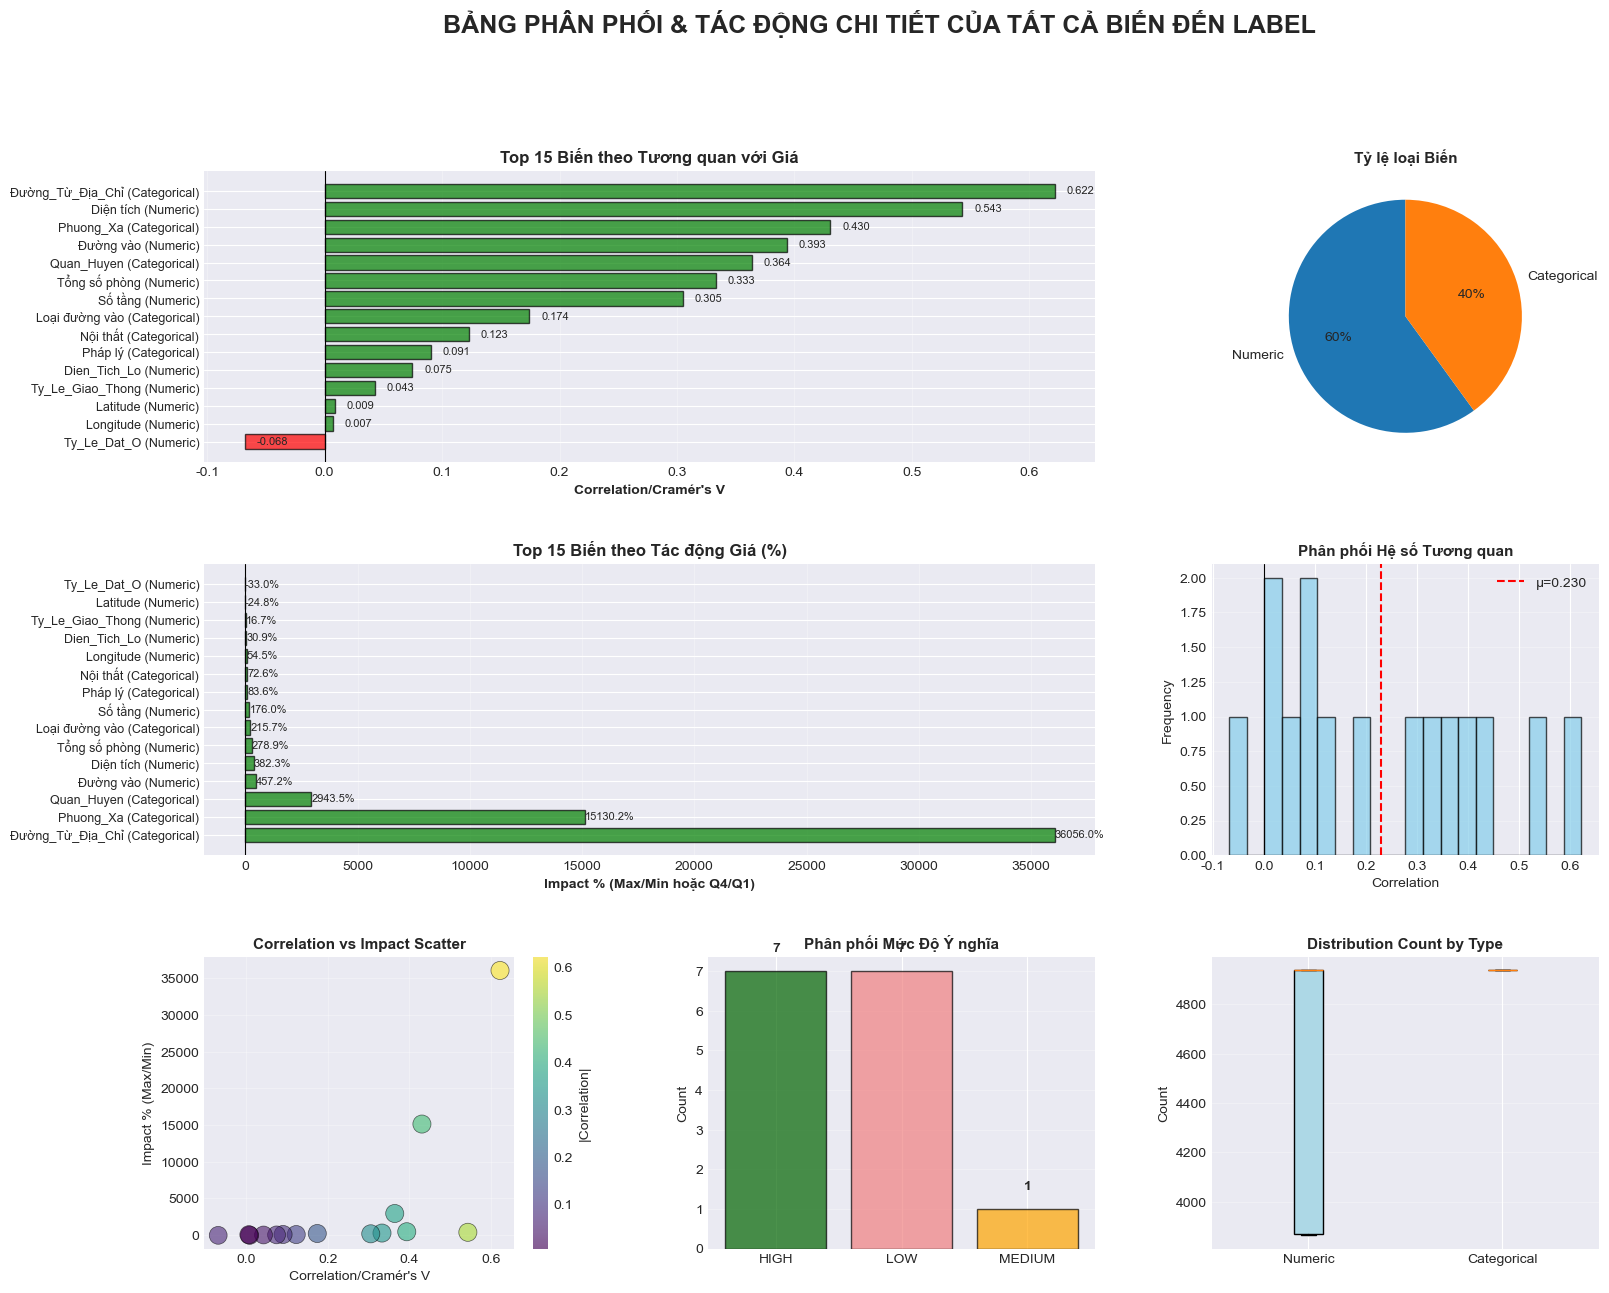


[THỐNG KÊ TỔNG HỢP]
    • Tổng số biến phân tích: 15
    • Biến số: 9
    • Biến phân loại: 6

    • Biến có tác động HIGH: 7 (46.7%)
    • Biến có tác động MEDIUM: 1 (6.7%)
    • Biến có tác động LOW: 7 (46.7%)

    • Tương quan trung bình: 0.2296
    • Tác động % trung bình: 3722.69%

[BẢNG CHI TIẾT] TẤT CẢ BIẾN - SẮP XẾP THEO TƯƠNG QUAN:
         Feature        Type  Correlation  Impact_%     Mean      Std  Count Significance
Đường_Từ_Địa_Chỉ Categorical       0.6216  36056.04    20.50    37.92   4937         HIGH
       Diện tích     Numeric       0.5429    382.29    99.65    92.25   4937         HIGH
       Phuong_Xa Categorical       0.4305  15130.17    20.50    37.92   4937         HIGH
       Đường vào     Numeric       0.3934    457.21     9.60     6.68   4937         HIGH
      Quan_Huyen Categorical       0.3640   2943.51    20.50    37.92   4937         HIGH
   Tổng số phòng     Numeric       0.3328    278.86     9.89     8.68   4937         HIGH
         Số tầng     Numer

In [8]:
# ============================================================================
# PHẦN 18: BẢNG PHÂN PHỐI CHI TIẾT CỦA TẤT CẢ BIẾN & TÁC ĐỘNG ĐẾN LABEL
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

print("\n" + "="*80)
print("PHẦN 18: BẢNG PHÂN PHỐI & TÁC ĐỘNG CHI TIẾT CỦA TẤT CẢ BIẾN")
print("="*80)

# -------------------------------------------------------------------------
# -------------------------------------------------------------------------
# TỰ ĐỘNG KHÔI PHỤC VÀ CẬP NHẬT BIẾN (SỬA LỖI MẤT CỘT DIỆN TÍCH)
# -------------------------------------------------------------------------
if 'target_col' not in locals() and 'target_col' not in globals():
    target_col = 'Khoảng giá'  

if 'df_eda' in locals() or 'df_eda' in globals():
    # Bước 1: Kiểm tra nếu 'Diện tích' là kiểu chữ (Object), tự động làm sạch và ép về kiểu số
    if 'Diện tích' in df_eda.columns:
        if df_eda['Diện tích'].dtype == 'object':
            # Xóa chữ m2, m², khoảng trắng và đổi dấu phẩy thành dấu chấm nếu có
            df_eda['Diện tích'] = df_eda['Diện tích'].astype(str).str.replace('m²', '', case=False).str.replace('m2', '', case=False).str.strip()
            df_eda['Diện tích'] = df_eda['Diện tích'].str.replace(',', '.')
            df_eda['Diện tích'] = pd.to_numeric(df_eda['Diện tích'], errors='coerce')
            print("[✓] Đã ép kiểu cột 'Diện tích' từ Object về Dạng Số thành công!")

    # Bước 2: Dùng 'number' để quét SẠCH TẤT CẢ các kiểu số (int32, int64, float32, float64,...)
    numeric_cols = df_eda.select_dtypes(include=['number']).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)
        
    # Bước 3: Quét lại toàn bộ cột chữ/phân loại còn lại
    all_categorical = df_eda.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    if target_col in all_categorical:
        all_categorical.remove(target_col)
        
    print(f"[i] Danh sách cột số tìm thấy: {numeric_cols}")
else:
    raise NameError("Không tìm thấy biến 'df_eda'. Bạn cần nhấn Run cell load dữ liệu (CELL 1) trước đã!")
# -------------------------------------------------------------------------
# -------------------------------------------------------------------------

# Tạo bảng tổng hợp: TẤT CẢ BIẾN (số + phân loại)
all_features_impact = []

# 1. Biến số
for col in numeric_cols:
    try:
        valid_mask = df_eda[col].notna() & df_eda[target_col].notna()
        col_data = df_eda.loc[valid_mask, col]
        target_valid = df_eda.loc[valid_mask, target_col]
        
        correlation = col_data.corr(target_valid)
        
        quartile_labels = pd.qcut(col_data, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
        price_by_quartile = target_valid.groupby(quartile_labels).agg(['mean', 'median', 'count', 'std'])
        
        try:
            price_ratio = price_by_quartile.loc['Q4', ('mean', '')] / price_by_quartile.loc['Q1', ('mean', '')] if price_by_quartile.loc['Q1', ('mean', '')] > 0 else 0
        except:
            price_ratio = price_by_quartile.loc['Q4', 'mean'] / price_by_quartile.loc['Q1', 'mean'] if price_by_quartile.loc['Q1', 'mean'] > 0 else 0
        
        price_diff_pct = (price_ratio - 1) * 100
        
        all_features_impact.append({
            'Feature': col,
            'Type': 'Numeric',
            'Correlation': round(correlation, 4),
            'Impact_%': round(price_diff_pct, 2),
            'Min': round(col_data.min(), 2),
            'Max': round(col_data.max(), 2),
            'Mean': round(col_data.mean(), 2),
            'Median': round(col_data.median(), 2),
            'Std': round(col_data.std(), 2),
            'Count': col_data.count(),
            'Significance': 'HIGH' if abs(correlation) > 0.3 else ('MEDIUM' if abs(correlation) > 0.15 else 'LOW')
        })
    except:
        pass

# 2. Biến phân loại
for col in all_categorical:
    try:
        valid_mask = df_eda[col].notna() & df_eda[target_col].notna()
        col_data = df_eda.loc[valid_mask, col]
        target_valid = df_eda.loc[valid_mask, target_col]
        
        grouped = target_valid.groupby(col_data)
        group_means = grouped.mean().sort_values(ascending=False)
        
        if len(group_means) >= 2:
            max_price = group_means.iloc[0]
            min_price = group_means.iloc[-1]
            price_ratio = max_price / (min_price + 0.001) if min_price > 0 else 0
            price_diff_pct = (price_ratio - 1) * 100
        else:
            price_diff_pct = 0
        
        # Tính Cramér's V
        contingency_table = pd.crosstab(col_data, pd.qcut(target_valid, q=3, labels=['Low', 'Mid', 'High'], duplicates='drop'))
        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
            chi2, p_value, dof, expected = chi2_contingency(contingency_table)
            cramers_v = np.sqrt(chi2 / (len(target_valid) * (min(contingency_table.shape) - 1)))
        else:
            cramers_v = 0
        
        all_features_impact.append({
            'Feature': col,
            'Type': 'Categorical',
            'Correlation': round(cramers_v, 4),
            'Impact_%': round(price_diff_pct, 2),
            'Min': round(target_valid.min(), 2),
            'Max': round(target_valid.max(), 2),
            'Mean': round(target_valid.mean(), 2),
            'Median': round(target_valid.median(), 2),
            'Std': round(target_valid.std(), 2),
            'Count': col_data.count(),
            'Significance': 'HIGH' if cramers_v > 0.3 else ('MEDIUM' if cramers_v > 0.15 else 'LOW')
        })
    except:
        pass

# Tạo DataFrame tổng hợp
all_impact_df = pd.DataFrame(all_features_impact)
all_impact_df['Abs_Corr'] = all_impact_df['Correlation'].abs()
all_impact_df = all_impact_df.sort_values('Abs_Corr', ascending=False)

print(f"\n[✓] BẢNG TÓM TẮT TẤT CẢ {len(all_impact_df)} BIẾN:")
print("\n" + all_impact_df[['Feature', 'Type', 'Correlation', 'Impact_%', 'Count', 'Significance']].to_string(index=False))

# Tạo visualizations toàn diện
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

fig.suptitle('BẢNG PHÂN PHỐI & TÁC ĐỘNG CHI TIẾT CỦA TẤT CẢ BIẾN ĐẾN LABEL', 
             fontsize=18, fontweight='bold', y=0.995)

# 1. Top 15 biến theo tương quan
ax1 = fig.add_subplot(gs[0, :2])
top_corr_all = all_impact_df.head(15).sort_values('Correlation', ascending=True)
colors = ['green' if x > 0 else 'red' for x in top_corr_all['Correlation']]
bars = ax1.barh(range(len(top_corr_all)), top_corr_all['Correlation'], color=colors, alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(top_corr_all)))
ax1.set_yticklabels([f"{f} ({t})" for f, t in zip(top_corr_all['Feature'], top_corr_all['Type'])], fontsize=9)
ax1.set_xlabel('Correlation/Cramér\'s V', fontweight='bold')
ax1.set_title('Top 15 Biến theo Tương quan với Giá', fontweight='bold', fontsize=12)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(top_corr_all.iterrows()):
    ax1.text(row['Correlation'] + 0.01, i, f"{row['Correlation']:.3f}", va='center', fontsize=8)

# 2. Pie chart: Loại biến
ax2 = fig.add_subplot(gs[0, 2])
type_counts = all_impact_df['Type'].value_counts()
colors_pie = ['#1f77b4', '#ff7f0e']
ax2.pie(type_counts.values, labels=type_counts.index, autopct='%1.0f%%', colors=colors_pie, startangle=90)
ax2.set_title('Tỷ lệ loại Biến', fontweight='bold', fontsize=11)

# 3. Top 15 theo Impact %
ax3 = fig.add_subplot(gs[1, :2])
top_impact_all = all_impact_df.nlargest(15, 'Impact_%')
colors_impact = ['green' if x > 0 else 'red' for x in top_impact_all['Impact_%']]
ax3.barh(range(len(top_impact_all)), top_impact_all['Impact_%'].values, color=colors_impact, alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(top_impact_all)))
ax3.set_yticklabels([f"{f} ({t})" for f, t in zip(top_impact_all['Feature'], top_impact_all['Type'])], fontsize=9)
ax3.set_xlabel('Impact % (Max/Min hoặc Q4/Q1)', fontweight='bold')
ax3.set_title('Top 15 Biến theo Tác động Giá (%)', fontweight='bold', fontsize=12)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax3.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(top_impact_all.iterrows()):
    ax3.text(row['Impact_%'] + 1 if row['Impact_%'] > 0 else row['Impact_%'] - 1, i, f"{row['Impact_%']:.1f}%", va='center', fontsize=8)

# 4. Distribution Correlation
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(all_impact_df['Correlation'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(x=all_impact_df['Correlation'].mean(), color='red', linestyle='--', label=f'μ={all_impact_df["Correlation"].mean():.3f}')
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_xlabel('Correlation')
ax4.set_ylabel('Frequency')
ax4.set_title('Phân phối Hệ số Tương quan', fontweight='bold', fontsize=11)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 5. Correlation vs Impact scatter
ax5 = fig.add_subplot(gs[2, 0])
scatter = ax5.scatter(all_impact_df['Correlation'], all_impact_df['Impact_%'], 
                      s=np.log(all_impact_df['Count'].values + 1) * 20, 
                      c=all_impact_df['Abs_Corr'], cmap='viridis', 
                      alpha=0.6, edgecolors='black', linewidth=0.5)
ax5.set_xlabel('Correlation/Cramér\'s V')
ax5.set_ylabel('Impact % (Max/Min)')
ax5.set_title('Correlation vs Impact Scatter', fontweight='bold', fontsize=11)
ax5.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax5, label='|Correlation|')

# 6. Significance distribution
ax6 = fig.add_subplot(gs[2, 1])
sig_counts = all_impact_df['Significance'].value_counts()
colors_sig = {'HIGH': 'darkgreen', 'MEDIUM': 'orange', 'LOW': 'lightcoral'}
sig_colors = [colors_sig.get(cat, 'gray') for cat in sig_counts.index]
ax6.bar(range(len(sig_counts)), sig_counts.values, color=sig_colors, alpha=0.7, edgecolor='black')
ax6.set_xticks(range(len(sig_counts)))
ax6.set_xticklabels(sig_counts.index)
ax6.set_ylabel('Count')
ax6.set_title('Phân phối Mức Độ Ý nghĩa', fontweight='bold', fontsize=11)
ax6.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(sig_counts.values):
    ax6.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# 7. Box plot: Count by Type
ax7 = fig.add_subplot(gs[2, 2])
data_for_box = [all_impact_df[all_impact_df['Type'] == 'Numeric']['Count'].values,
                all_impact_df[all_impact_df['Type'] == 'Categorical']['Count'].values]
bp = ax7.boxplot(data_for_box, labels=['Numeric', 'Categorical'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)
ax7.set_ylabel('Count')
ax7.set_title('Distribution Count by Type', fontweight='bold', fontsize=11)
ax7.grid(True, alpha=0.3, axis='y')

plt.show()

# Thống kê tổng hợp
print("\n[THỐNG KÊ TỔNG HỢP]")
print(f"    • Tổng số biến phân tích: {len(all_impact_df)}")
print(f"    • Biến số: {len(all_impact_df[all_impact_df['Type']=='Numeric'])}")
print(f"    • Biến phân loại: {len(all_impact_df[all_impact_df['Type']=='Categorical'])}")
print(f"\n    • Biến có tác động HIGH: {len(all_impact_df[all_impact_df['Significance']=='HIGH'])} ({len(all_impact_df[all_impact_df['Significance']=='HIGH'])/len(all_impact_df)*100:.1f}%)")
print(f"    • Biến có tác động MEDIUM: {len(all_impact_df[all_impact_df['Significance']=='MEDIUM'])} ({len(all_impact_df[all_impact_df['Significance']=='MEDIUM'])/len(all_impact_df)*100:.1f}%)")
print(f"    • Biến có tác động LOW: {len(all_impact_df[all_impact_df['Significance']=='LOW'])} ({len(all_impact_df[all_impact_df['Significance']=='LOW'])/len(all_impact_df)*100:.1f}%)")
print(f"\n    • Tương quan trung bình: {all_impact_df['Correlation'].mean():.4f}")
print(f"    • Tác động % trung bình: {all_impact_df['Impact_%'].mean():.2f}%")

# Xuất bảng chi tiết
print("\n[BẢNG CHI TIẾT] TẤT CẢ BIẾN - SẮP XẾP THEO TƯƠNG QUAN:")
display_all = all_impact_df[['Feature', 'Type', 'Correlation', 'Impact_%', 'Mean', 'Std', 'Count', 'Significance']]
print(display_all.to_string(index=False))

In [ ]:

# ============================================================================
# PHẦN 19: PHÂN TÍCH CHI TIẾT DISTRIBUTION CỦA TOP 20 BIẾN QUAN TRỌNG
# ============================================================================

print("\n" + "="*80)
print("PHẦN 19: PHÂN TÍCH CHI TIẾT DISTRIBUTION CỦA TOP 20 BIẾN QUAN TRỌNG")
print("="*80)

# Lấy top 20 biến
top_20_features = all_impact_df.head(20)

print(f"\n[✓] Phân tích chi tiết {len(top_20_features)} biến quan trọng nhất")

# Tạo table chi tiết từng biến
for idx, (i, feature_row) in enumerate(top_20_features.iterrows(), 1):
    feature_name = feature_row['Feature']
    feature_type = feature_row['Type']
    
    print(f"\n{'='*80}")
    print(f"{idx}. BIẾN: {feature_name} ({feature_type})")
    print(f"{'='*80}")
    
    valid_mask = df_eda[feature_name].notna() & df_eda[target_col].notna()
    col_data = df_eda.loc[valid_mask, feature_name]
    target_valid = df_eda.loc[valid_mask, target_col]
    
    if feature_type == 'Numeric':
        # Bảng phân phối theo quartiles
        quartile_labels = pd.qcut(col_data, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
        distribution_by_quartile = target_valid.groupby(quartile_labels).agg([
            ('Count', 'count'),
            ('Price_Mean', 'mean'),
            ('Price_Median', 'median'),
            ('Price_Std', 'std'),
            ('Price_Min', 'min'),
            ('Price_Max', 'max'),
            ('% of Total', lambda x: (len(x) / len(target_valid) * 100))
        ]).round(4)
        
        print(f"\n[DISTRIBUTION] Phân phối giá theo Quartiles:")
        print(distribution_by_quartile.to_string())
        
        # Thống kê biến
        print(f"\n[STATISTICS] Thống kê {feature_name}:")
        print(f"    • Count: {col_data.count()}")
        print(f"    • Missing: {col_data.isna().sum()}")
        print(f"    • Min: {col_data.min():.4f}")
        print(f"    • Q1 (25%): {col_data.quantile(0.25):.4f}")
        print(f"    • Median: {col_data.median():.4f}")
        print(f"    • Q3 (75%): {col_data.quantile(0.75):.4f}")
        print(f"    • Max: {col_data.max():.4f}")
        print(f"    • Mean: {col_data.mean():.4f}")
        print(f"    • Std: {col_data.std():.4f}")
        print(f"    • Skewness: {col_data.skew():.4f}")
        print(f"    • Kurtosis: {col_data.kurtosis():.4f}")
        
    else:
        # Phân loại - phân phối theo từng giá trị
        distribution_by_category = target_valid.groupby(col_data).agg([
            ('Count', 'count'),
            ('Price_Mean', 'mean'),
            ('Price_Median', 'median'),
            ('Price_Std', 'std'),
            ('Price_Min', 'min'),
            ('Price_Max', 'max'),
            ('% of Total', lambda x: (len(x) / len(target_valid) * 100))
        ]).round(4).sort_values('Count', ascending=False)
        
        print(f"\n[DISTRIBUTION] Phân phối giá theo Giá trị Phân loại:")
        print(distribution_by_category.to_string())
        
        print(f"\n[STATISTICS] Thống kê {feature_name}:")
        print(f"    • Count: {col_data.count()}")
        print(f"    • Missing: {col_data.isna().sum()}")
        print(f"    • Unique Values: {col_data.nunique()}")
        print(f"    • Mode: {col_data.mode().values[0] if len(col_data.mode()) > 0 else 'N/A'}")
    
    print(f"\n[IMPACT] Tác động đến Label ({target_col}):")
    print(f"    • Correlation/Cramér's V: {feature_row['Correlation']:.4f}")
    print(f"    • Impact %: {feature_row['Impact_%']:.2f}%")
    print(f"    • Significance: {feature_row['Significance']}")

print("\n" + "="*80)
print("[✓] PHÂN TÍCH CHI TIẾT HOÀN TẤT")
print("="*80)



PHẦN 19: PHÂN TÍCH CHI TIẾT DISTRIBUTION CỦA TOP 20 BIẾN QUAN TRỌNG

[✓] Phân tích chi tiết 8 biến quan trọng nhất

1. BIẾN: Đường vào (Numeric)

[DISTRIBUTION] Phân phối giá theo Quartiles:
           Count  Price_Mean  Price_Median  Price_Std  Price_Min  Price_Max  % of Total
Đường vào                                                                              
Q1          1289      8.2105          6.80     8.5789       1.02      225.0     26.1090
Q2          1627     12.7813          8.90    14.9854       1.98      380.0     32.9552
Q3           973     22.4979         13.80    33.5725       1.05      350.0     19.7083
Q4          1048     45.7496         24.25    66.1412       1.36      650.0     21.2275

[STATISTICS] Thống kê Đường vào:
    • Count: 4937
    • Missing: 0
    • Min: 1.0000
    • Q1 (25%): 5.0000
    • Median: 8.0000
    • Q3 (75%): 12.0000
    • Max: 50.0000
    • Mean: 9.6015
    • Std: 6.6844
    • Skewness: 1.9264
    • Kurtosis: 4.6504

[IMPACT] Tác động đến 


CELL 20: DASHBOARD TÍCH HỢP TOÀN DIỆN THỊ TRƯỜNG THEO QUẬN / HUYỆN


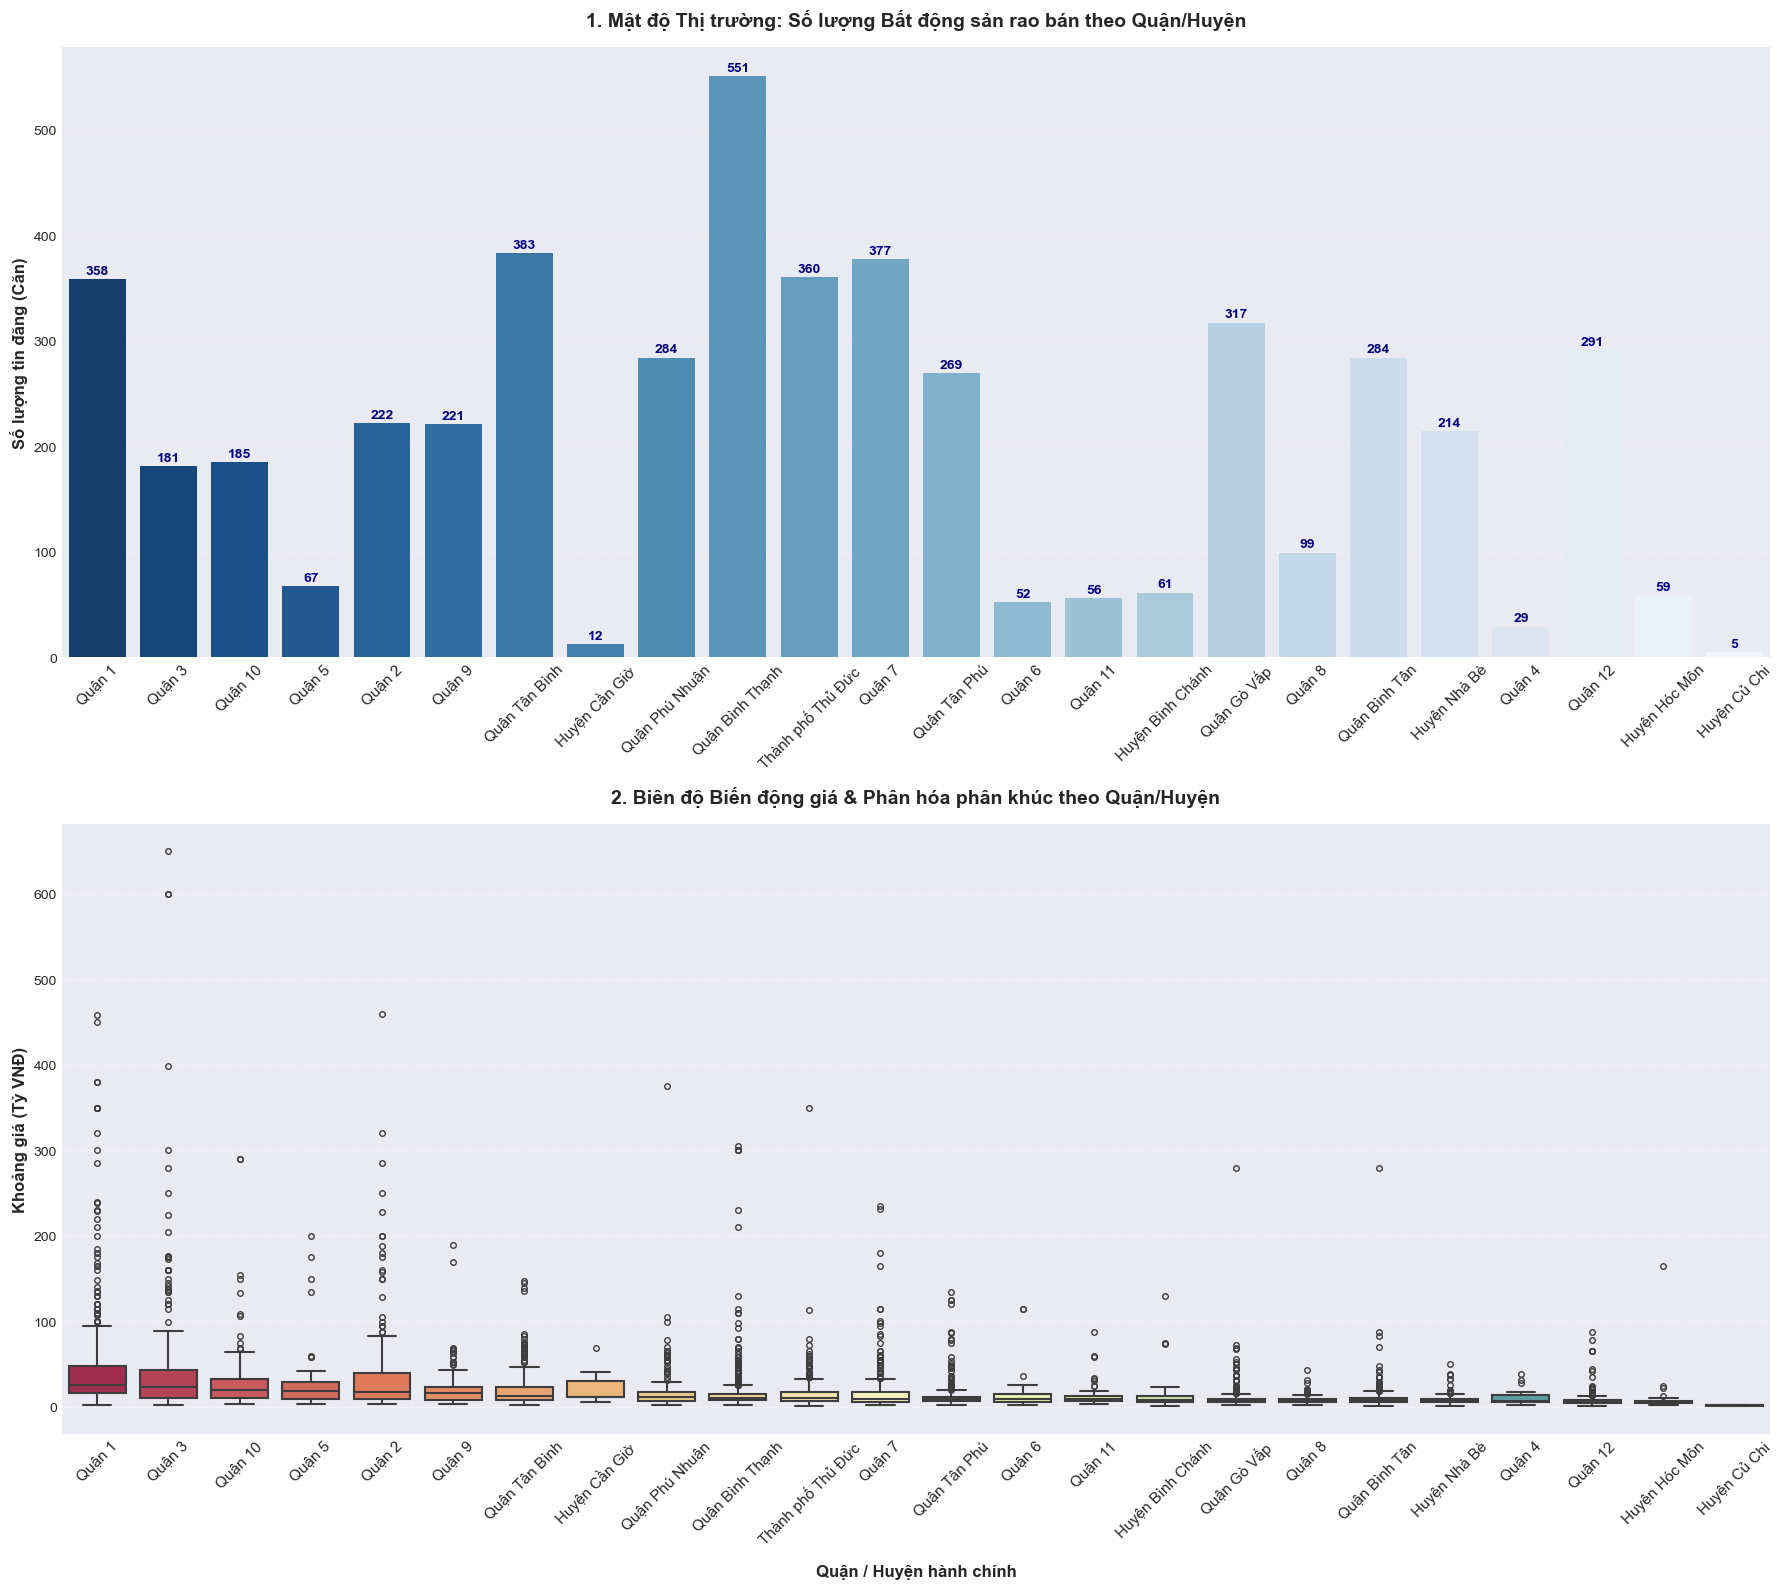


--------------------------------------------------------------------------------
BẢNG ĐỐI CHIẾU SỐ LIỆU TÍCH HỢP (Đã sắp xếp theo mức giá trung vị giảm dần):
--------------------------------------------------------------------------------
       Quan_Huyen  So_Luong_Tin_Dang Ty_Le_Phan_Tram Gia_Trung_Vi Gia_Trung_Binh
           Quận 1                358           7.25%     26.00 Tỷ       50.56 Tỷ
           Quận 3                181           3.67%     22.80 Tỷ       54.33 Tỷ
          Quận 10                185           3.75%     19.90 Tỷ       28.05 Tỷ
           Quận 5                 67           1.36%     18.50 Tỷ       28.22 Tỷ
           Quận 2                222           4.50%     17.50 Tỷ       37.44 Tỷ
           Quận 9                221           4.48%     16.50 Tỷ       19.47 Tỷ
    Quận Tân Bình                383           7.76%     12.80 Tỷ       20.01 Tỷ
    Huyện Cần Giờ                 12           0.24%     12.00 Tỷ       22.61 Tỷ
   Quận Phú Nhuận              

In [ ]:
# CELL 14: Integrated District Analysis Dashboard (Volume Bar Plot & Price Box Plot)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("CELL 20: DASHBOARD TÍCH HỢP TOÀN DIỆN THỊ TRƯỜNG THEO QUẬN / HUYỆN")
print("="*80)

# Định nghĩa các cột mục tiêu
target_col = 'Khoảng giá'
district_col = 'Quan_Huyen'

# Bước 1: Tính toán bảng thống kê và lấy thứ tự Quận theo Giá Trung vị (Median) giảm dần
district_stats = df_eda.groupby(district_col).agg(
    So_Luong_Tin_Dang=(target_col, 'count'),
    Gia_Trung_Vi=(target_col, 'median'),
    Gia_Trung_Binh=(target_col, 'mean')
).reset_index()

# Sắp xếp danh sách quận theo giá trung vị giảm dần để làm chuẩn hiển thị cho cả 2 đồ thị
district_order = district_stats.sort_values(by='Gia_Trung_Vi', ascending=False)[district_col].values
stats_sorted = district_stats.set_index(district_col).loc[district_order].reset_index()

# Tính tỷ lệ phần trăm đóng góp tin đăng của từng quận
total_listings = stats_sorted['So_Luong_Tin_Dang'].sum()
stats_sorted['Ty_Le_Phan_Tram'] = (stats_sorted['So_Luong_Tin_Dang'] / total_listings) * 100


# -------------------------------------------------------------------------
# BƯỚC 2: KHỞI TẠO KHÔNG GIAN ĐỒ THỊ KÉP (2 HÀNG x 1 CỘT)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(18, 16), sharex=False)

# BIỂU ĐỒ 1 (TRÊN): SỐ LƯỢNG TIN ĐĂNG (MẬT ĐỘ THỊ TRƯỜNG)
sns.barplot(
    data=stats_sorted,
    x=district_col,
    y='So_Luong_Tin_Dang',
    palette='Blues_r', # Tone xanh dương đậm đến nhạt dần
    order=district_order,
    ax=axes[0]
)
axes[0].set_title('1. Mật độ Thị trường: Số lượng Bất động sản rao bán theo Quận/Huyện', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Số lượng tin đăng (Căn)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('', labelpad=0) # Ẩn label x ở biểu đồ trên cho thoáng
axes[0].tick_params(axis='x', rotation=45, labelsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Điền số lượng tin đăng lên đầu mỗi cột
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', xytext=(0, 6), 
                     textcoords='offset points', fontsize=10, fontweight='bold', color='navy')


# BIỂU ĐỒ 2 (DƯỚI): BOX PLOT PHÂN PHỐI GIÁ CHI TIẾT
sns.boxplot(
    data=df_eda,
    x=district_col,
    y=target_col,
    order=district_order,
    palette='Spectral', # Thang màu cầu vồng Spectral phân tách rõ các vùng
    fliersize=4,        # Hiển thị các căn siêu biệt thự (outliers)
    linewidth=1.5,
    ax=axes[1]
)
axes[1].set_title('2. Biên độ Biến động giá & Phân hóa phân khúc theo Quận/Huyện', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Khoảng giá (Tỷ VNĐ)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quận / Huyện hành chính', fontsize=12, fontweight='bold', labelpad=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa không gian hiển thị tránh đè chữ
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# BƯỚC 3: XUẤT THỐNG KÊ CHI TIẾT VÀ NHẬN ĐỊNH BÁO CÁO (INSIGHTS)
# -------------------------------------------------------------------------
print("\n" + "-"*80)
print("BẢNG ĐỐI CHIẾU SỐ LIỆU TÍCH HỢP (Đã sắp xếp theo mức giá trung vị giảm dần):")
print("-"*80)
print(stats_sorted[['Quan_Huyen', 'So_Luong_Tin_Dang', 'Ty_Le_Phan_Tram', 'Gia_Trung_Vi', 'Gia_Trung_Binh']].to_string(index=False, formatters={
    'Ty_Le_Phan_Tram': '{:.2f}%'.format,
    'Gia_Trung_Vi': '{:.2f} Tỷ'.format,
    'Gia_Trung_Binh': '{:.2f} Tỷ'.format
}))

print("\n" + "="*80)
print("TÓM TẮT INSIGHT ĐẮT GIÁ TỪ DASHBOARD TÍCH HỢP:")
print("="*80)
# Trích xuất nhanh các thông số để tự động hóa nhận định
highest_district = stats_sorted.iloc[0]
lowest_district = stats_sorted.iloc[-1]
most_crowded = stats_sorted.sort_values(by='So_Luong_Tin_Dang', ascending=False).iloc[0]

print(f"1. [ĐỘ LỆCH GIÁ - KHÔNG GIAN]: Mức giá trung vị cao nhất thuộc về '{highest_district[district_col]}' ({highest_district['Gia_Trung_Vi']:.2f} Tỷ), ")
print(f"   trong khi thấp nhất là '{lowest_district[district_col]}' ({lowest_district['Gia_Trung_Vi']:.2f} Tỷ). Sự chênh lệch này giải thích vì sao")
print(f"   biến vị trí địa lý luôn có trọng số cao nhất.")
print(f"\n2. [MỐI QUAN HỆ GIỮA GIÁ & THỂ TÍCH MẪU]:")
print(f"   - Hãy nhìn vào biểu đồ cột phía trên: Các quận đắt đỏ top đầu thường có lượng tin đăng khá khiêm tốn.")
print(f"   - Thị trường tập trung lượng mẫu 'khủng' nhất tại '{most_crowded[district_col]}' với {most_crowded['So_Luong_Tin_Dang']} căn ")
print(f"     (chiếm {most_crowded['Ty_Le_Phan_Tram']:.2f}% dữ liệu), nhưng quận này lại nằm ở phân khúc giá trung bình-thấp trên Box Plot.")
print(f"\n3. [TƯ DUY TIỀN XỬ LÝ CHO MÔ HÌNH]:")
print(f"   - Outliers (Dấu chấm rời rạc): Các quận trung tâm có râu hộp kéo rất dài và xuất hiện nhiều outlier vọt lên.")
print(f"     Điều này chứng tỏ phân khúc cao cấp bị nhiễu mạnh bởi các căn siêu giá trị.")
print(f"   - Ứng dụng: Khi dùng mô hình Machine Learning, biến '{district_col}' cần được mã hóa bằng Target Encoding ")
print(f"     (mã hóa bằng chính giá trị Mean/Median của giá nhà) để mô hình tận dụng được cấu trúc phân tầng hoàn hảo này.")


CELL 21: PHÂN TÍCH TƯƠNG TÁC GIỮA CUNG (SỐ LƯỢNG) VÀ BIẾN ĐỘNG GIÁ
[+] Chỉ số toán học thu được:
    - Tương quan giữa Số lượng & Mức giá Trung vị: r = 0.288
    - Tương quan giữa Số lượng & Biên độ dao động giá: r = 0.355


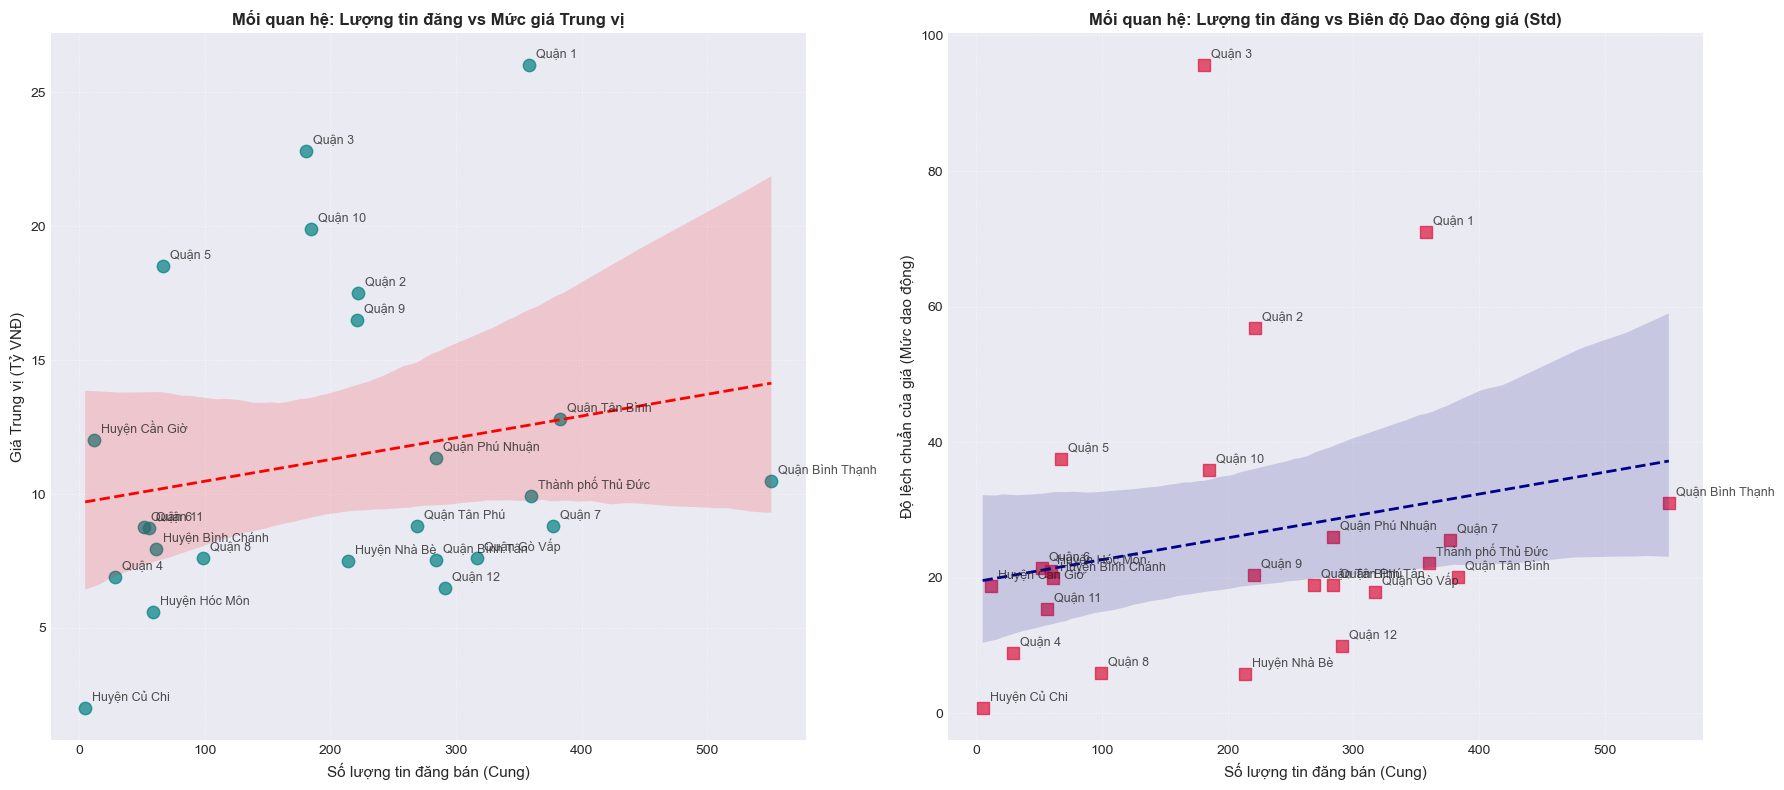

In [ ]:
# CELL 16: Deep Relational Analysis - Supply (Volume) vs Price Volatility (Volatility)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("CELL 21: PHÂN TÍCH TƯƠNG TÁC GIỮA CUNG (SỐ LƯỢNG) VÀ BIẾN ĐỘNG GIÁ")
print("="*80)

target_col = 'Khoảng giá'
district_col = 'Quan_Huyen'

# -------------------------------------------------------------------------
# BƯỚC 1: GỘP DỮ LIỆU CẤP QUẬN - ĐỊNH NGHĨA "SỐ LƯỢNG" VÀ "DAO ĐỘNG GIÁ"
# -------------------------------------------------------------------------
# Dao động giá được đo bằng:
# - Độ lệch chuẩn (Std): Mức độ phân tán của giá so với trung bình.
# - IQR (Interquartile Range): Biên độ giá của 50% phân khúc lõi (Ít bị nhiễu bởi siêu biệt thự).
market_relation = df_eda.groupby(district_col).agg(
    So_Luong_Tin_Dang=(target_col, 'count'),
    Gia_Trung_Vi=(target_col, 'median'),
    Do_Lech_Chuan_Gia=(target_col, 'std'),
    IQR_Gia=(target_col, lambda x: x.quantile(0.75) - x.quantile(0.25))
).reset_index().fillna(0)

# -------------------------------------------------------------------------
# BƯỚC 2: TÍNH TOÁN HỆ SỐ TƯƠNG QUAN TOÁN HỌC (SPEARMAN)
# -------------------------------------------------------------------------
corr_volume_price = market_relation['So_Luong_Tin_Dang'].corr(market_relation['Gia_Trung_Vi'], method='spearman')
corr_volume_volatility = market_relation['So_Luong_Tin_Dang'].corr(market_relation['Do_Lech_Chuan_Gia'], method='spearman')

print(f"[+] Chỉ số toán học thu được:")
print(f"    - Tương quan giữa Số lượng & Mức giá Trung vị: r = {corr_volume_price:.3f}")
print(f"    - Tương quan giữa Số lượng & Biên độ dao động giá: r = {corr_volume_volatility:.3f}")


# -------------------------------------------------------------------------
# BƯỚC 3: TRỰC QUAN HÓA BẰNG ĐỒ THỊ PHÂN TÁN (SCATTER PLOT + REGRESSION LINE)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Đồ thị 1: Số lượng tin đăng vs Mức giá Trung vị
sns.regplot(
    data=market_relation,
    x='So_Luong_Tin_Dang',
    y='Gia_Trung_Vi',
    ax=axes[0],
    color='teal',
    marker='o',
    scatter_kws={'s': 80, 'alpha': 0.7},
    line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'}
)
axes[0].set_title('Mối quan hệ: Lượng tin đăng vs Mức giá Trung vị', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số lượng tin đăng bán (Cung)', fontsize=11)
axes[0].set_ylabel('Giá Trung vị (Tỷ VNĐ)', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Gắn tên quận lên từng chấm tròn ở Đồ thị 1
for idx, row in market_relation.iterrows():
    axes[0].annotate(row[district_col], (row['So_Luong_Tin_Dang'], row['Gia_Trung_Vi']),
                     textcoords="offset points", xytext=(5,5), ha='left', fontsize=9, alpha=0.8)


# Đồ thị 2: Số lượng tin đăng vs Biên độ Dao động giá (Độ lệch chuẩn)
sns.regplot(
    data=market_relation,
    x='So_Luong_Tin_Dang',
    y='Do_Lech_Chuan_Gia',
    ax=axes[1],
    color='crimson',
    marker='s',
    scatter_kws={'s': 80, 'alpha': 0.7},
    line_kws={'color': 'darkblue', 'linewidth': 2, 'linestyle': '--'}
)
axes[1].set_title('Mối quan hệ: Lượng tin đăng vs Biên độ Dao động giá (Std)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số lượng tin đăng bán (Cung)', fontsize=11)
axes[1].set_ylabel('Độ lệch chuẩn của giá (Mức dao động)', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Gắn tên quận lên từng chấm vuông ở Đồ thị 2
for idx, row in market_relation.iterrows():
    axes[1].annotate(row[district_col], (row['So_Luong_Tin_Dang'], row['Do_Lech_Chuan_Gia']),
                     textcoords="offset points", xytext=(5,5), ha='left', fontsize=9, alpha=0.8)

plt.tight_layout()
plt.show()

Giá trị của các căn được rao bán phụ thuộc vô số lượng bài đăng & gần quận trung tâm => thể hiện thị trường nhộn nhịp với tiện ích mặc dù được rao bán nhiều trong cùng quận nhưng vẫn giữu dược mức giá khá cao do nhu cầu lớn, variance của giá cao xuất hiện ở các quận 1 và gần trung tâm vì kinh tế phát triển => xuất hiện 1 số biệt thự với tòa mặt tiền để kéo giá thị trường lên